### Pipeline

This script takes a single 2D TIFF frame, extracts a region of interest (ROI), removes a smooth background, and then uses juwavelet to identify and visualize the main gravity‐wave packets.

Pipeline:

1. Load the full TIFF as a 2D float32 array and compute the global mean and sigma.
2. Build a full-frame preview:
   - Mask pixels outside mean ± (SIGMA_FACTOR · σ).
   - Display the masked image with a fixed color range and draw the ROI rectangle.
3. Extract the ROI using X_SLICE and Y_SLICE.
4. Apply the same global mean ± σ range filter inside the ROI (optional), and fill “invalid” pixels (outside the range) so the ROI remains a full rectangle for the CWT.
5. Remove a smooth background from the ROI:
   - Fit and subtract a 2D plane (optional).
   - Extract and subtract the first Fourier components in x and y.
   - Define the “remaining” field = original − background.
6. Apply a Hanning edge taper to the remaining field (optional), then optionally despike it using a local median / MAD filter (DESPIKE_SIZE, DESPIKE_K).
7. Make a 4-panel figure showing:
   - Original (median-subtracted).
   - Background (plane + first Fourier).
   - Remaining = original − background.
   - Remaining with edge taper (and spikes removed).
8. Preprocess the tapered, despiked field for CWT:
   - Median-center and standardize (optional).
   - Apply a small Gaussian blur (optional).
9. Run 2D continuous wavelet transform with juwavelet.decompose2d using the specified S0, DJ, JS, JT, DX, DY, ASPECT.
10. Identify wave clusters in wavelet space with utils.identify_cluster2d (CLUSTER_MIN_AMP, CLUSTER_THR).
11. Plot:
    - A decomposition overview (utils.plot_decomposition2d).
    - A FOV wavelet spectrum (orientation vs wavelength) via plot_utils.plot_fov_wavelet_spectrum.
12. For the 9 strongest clusters:
    - Reconstruct each cluster back into physical space.
    - Plot 9 standalone cluster fields (median-centered).
    - Plot 9 overlays: each cluster on top of the tapered, despiked background field.

Outputs: one full-frame preview, one 4-panel background figure, a CWT summary figure, a polar FOV spectrum, 9 standalone cluster plots, and 9 cluster-on-background overlays.


### Animation, Find the Timeframe

Orbit #10293

Loaded 11 frames (from 0 to 10)
shape = (11, 256, 320)

UT times of displayed frames:
Frame    0  TempOH_caun0500.tif                       2025-09-16T07:21:16Z
Frame    1  TempOH_caun0501.tif                       2025-09-16T07:21:53Z
Frame    2  TempOH_caun0502.tif                       2025-09-16T07:22:30Z
Frame    3  TempOH_caun0503.tif                       2025-09-16T07:23:06Z
Frame    4  TempOH_caun0504.tif                       2025-09-16T07:23:43Z
Frame    5  TempOH_caun0505.tif                       2025-09-16T07:24:19Z
Frame    6  TempOH_caun0506.tif                       2025-09-16T07:24:56Z
Frame    7  TempOH_caun0507.tif                       2025-09-16T07:25:33Z
Frame    8  TempOH_caun0508.tif                       2025-09-16T07:26:09Z
Frame    9  TempOH_caun0509.tif                       2025-09-16T07:26:46Z
Frame   10  TempOH_caun0510.tif                       2025-09-16T07:27:22Z

center: 20130.60, sigma: 3984.99
use range: [18138.11, 22123.10]
Saved: C:\Users\domin\j

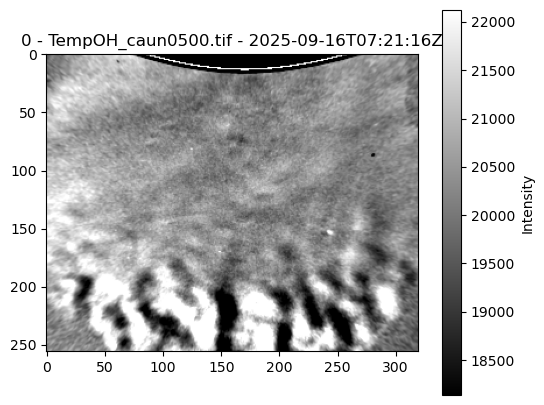

In [1]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import tifffile as tiff
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from datetime import datetime
from pathlib import Path

# --------------------
# User settings
# --------------------
FOLDER = Path().resolve()/ "Sep15-16(2025)"

FACTOR = 0.5          # center ± FACTOR * sigma range
START_INDEX = 0     # starting frame (0-based)
N_SHOW = 11          # number of frames to show

# --------------------
# Helper: read UT time from MTM TIFF header
# --------------------
def read_ut_time_from_tiff(path):
    """
    Read UT time from the custom MTM header inside the TIFF.

    Uses the offsets from the format document:
      247-250: UT second   (ULON)
      251-254: UT minute   (ULON)
      255-258: UT hour     (ULON)
      259-262: UT day      (ULON)
      263-266: UT month    (ULON, +1 = month)
      267-270: UT year     (ULON, +1900 = year)
    Byte order is little endian ("ll" in header).
    """
    import numpy as np

    with open(path, "rb") as f:
        header = f.read(300)  # enough to cover all time fields

    def u4(offset):
        # little-endian unsigned 4-byte integer
        return np.frombuffer(header[offset:offset+4], dtype="<u4")[0]

    sec   = int(u4(247))
    minute = int(u4(251))
    hour   = int(u4(255))
    day    = int(u4(259))
    month  = int(u4(263)) + 1     # +1 = month
    year   = int(u4(267)) + 1900  # +1900 = year

    return datetime(year, month, day, hour, minute, sec)

# --------------------
# Load all TIFFs
# --------------------
files_all = sorted(glob.glob(os.path.join(FOLDER, "*.tif")))
if not files_all:
    raise FileNotFoundError("No TIFFs found in folder.")

# Limit to desired range
files = files_all[START_INDEX: START_INDEX + N_SHOW]

frames = []
for f in files:
    img = tiff.imread(f)
    frames.append(img.astype(np.float32))

data = np.stack(frames, axis=0)

print(f"Loaded {len(files)} frames (from {START_INDEX} to {START_INDEX+len(files)-1})")
print(f"shape = {data.shape}")

# --------------------
# Read UT time for each displayed frame
# --------------------
times_utc = [read_ut_time_from_tiff(f) for f in files]

print("\nUT times of displayed frames:")
for i, (fname, t_utc) in enumerate(zip(files, times_utc)):
    frame_idx = START_INDEX + i
    print(f"Frame {frame_idx:4d}  {os.path.basename(fname):40s}  {t_utc.isoformat()}Z")

# --------------------
# Compute intensity range
# --------------------
sample = data.ravel()
center = float(np.mean(sample))
sigma = float(np.std(sample))

vmin = center - FACTOR * sigma
vmax = center + FACTOR * sigma

print(f"\ncenter: {center:.2f}, sigma: {sigma:.2f}")
print(f"use range: [{vmin:.2f}, {vmax:.2f}]")

# --------------------
# Plot animation
# --------------------
fig, ax = plt.subplots(figsize=(6, 5))

im = ax.imshow(
    np.clip(data[0], vmin, vmax),
    cmap="gray",
    vmin=vmin, vmax=vmax,
    origin="upper"
)

# Include frame index, filename, and UT time in the title
title = ax.set_title(
    f"{START_INDEX} - {os.path.basename(files[0])} - {times_utc[0].isoformat()}Z"
)
plt.colorbar(im, ax=ax, label="Intensity")

def update(i):
    im.set_data(np.clip(data[i], vmin, vmax))
    t_utc = times_utc[i]
    title.set_text(
        f"{START_INDEX + i} - {os.path.basename(files[i])} - {t_utc.isoformat()}Z"
    )
    return im, title

anim = FuncAnimation(fig, update, frames=len(files), interval=400, blit=False)

HTML(anim.to_jshtml())

# --------------------
# Save animation as MP4
# --------------------
out_mp4 = FOLDER / f"animation_{START_INDEX}_{START_INDEX+len(files)-1}.mp4"

anim.save(
    out_mp4,
    writer="ffmpeg",
    fps=2.5,          # 400 ms per frame ≈ 2.5 fps
    dpi=150
)

print("Saved:", out_mp4)


~ Frame 504  2025-09-16T07:23:43Z

## One Frame

[Full] mean: 20054.45
[Full] sigma: 3969.17
[Full] Clip range: [18466.79, 21642.12] = mean ± 0.40·sigma


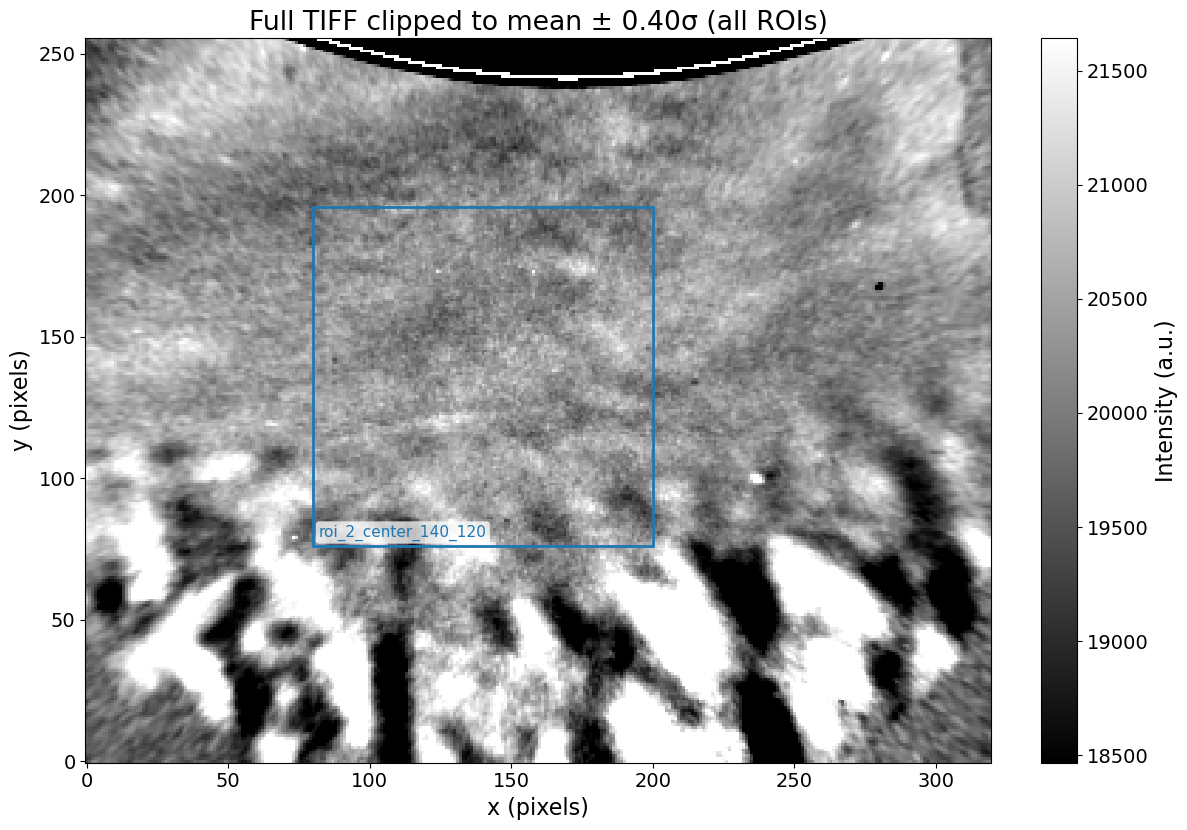


[ROI: roi_2_center_140_120] shape: (120, 120)   X=slice(80, 200, None)   Y=slice(60, 180, None)
[ROI: roi_2_center_140_120] Count: 14400
[ROI: roi_2_center_140_120] Min/max after clip: 18466.79 / 21642.12
[ROI: roi_2_center_140_120] Percentiles 5/50/95 (clipped): 19711.00 / 20326.00 / 20935.00


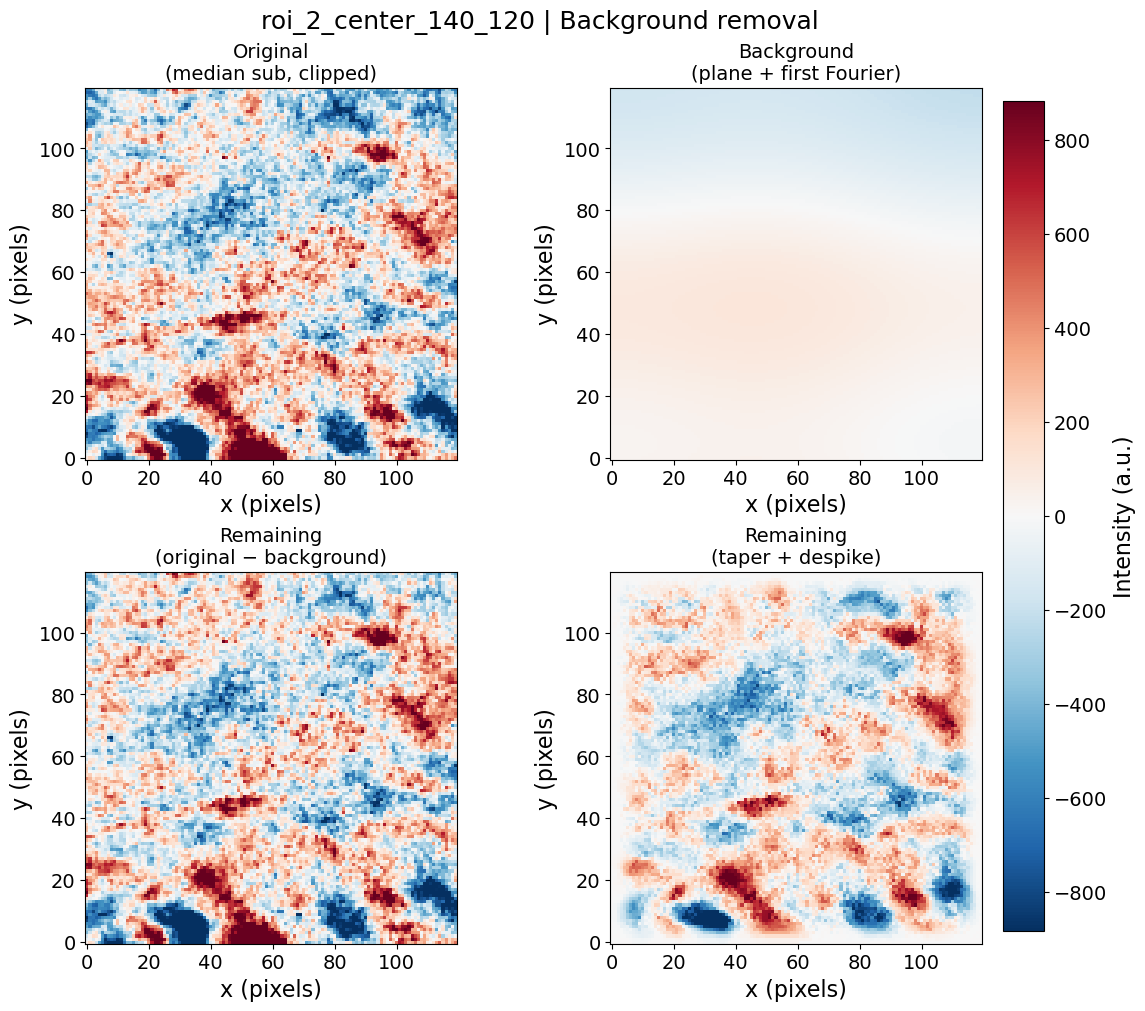

C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


------------
cluster= 0
amplitude= 0.47403220123853773 idx= (np.int64(8), np.int64(28), np.int64(39), np.int64(104))
selected elements: 567460
------------
cluster= 1
amplitude= 0.46569344919685307 idx= (np.int64(3), np.int64(21), np.int64(28), np.int64(109))
selected elements: 11842
------------
cluster= 2
amplitude= 0.4655951558211711 idx= (np.int64(2), np.int64(22), np.int64(29), np.int64(110))
selected elements: 3032
------------
cluster= 3
amplitude= 0.4487630211814103 idx= (np.int64(0), np.int64(17), np.int64(46), np.int64(73))
selected elements: 57538
------------
cluster= 4
amplitude= 0.446542295011268 idx= (np.int64(2), np.int64(23), np.int64(92), np.int64(24))
selected elements: 97657
------------
cluster= 5
amplitude= 0.4436782813271516 idx= (np.int64(3), np.int64(22), np.int64(90), np.int64(23))
selected elements: 252043
------------
cluster= 6
amplitude= 0.4330587494833309 idx= (np.int64(12), np.int64(24), np.int64(53), np.int64(103))
selected elements: 57070
------------


C:\Users\domin\juwavelet\juwavelet\utils.py:67: RuntimeWarning: divide by zero encountered in scalar divide
  hl = 1. / np.sin(theta[sel_t[j]])
100%|███████████████████████████████████████████████████████████████████████████████████| 3/3 [00:00<00:00, 118.12it/s]
C:\Users\domin\juwavelet\juwavelet\utils.py:94: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.tight_layout()


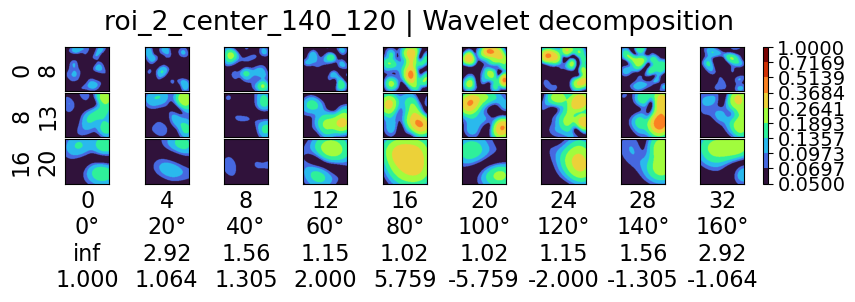

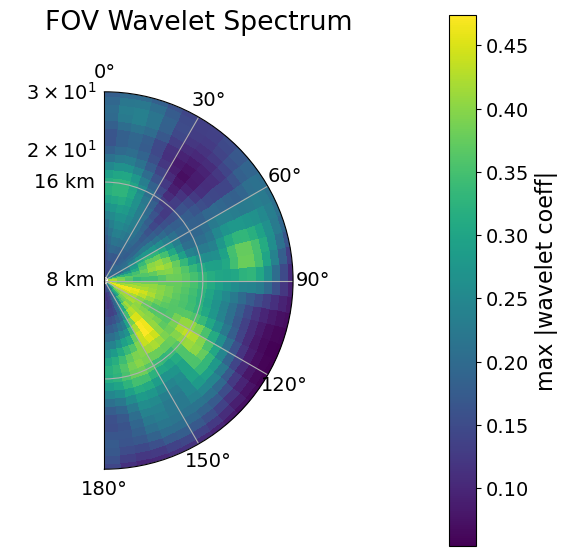

<Figure size 1388x858 with 0 Axes>

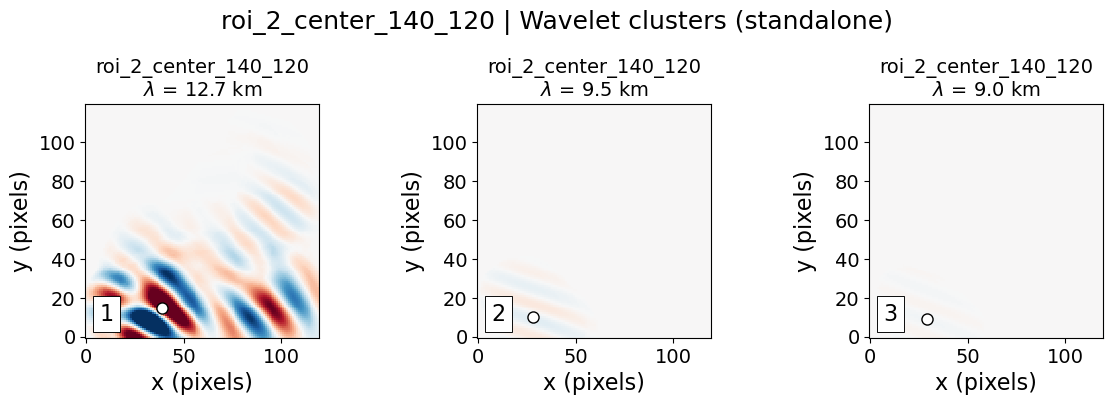

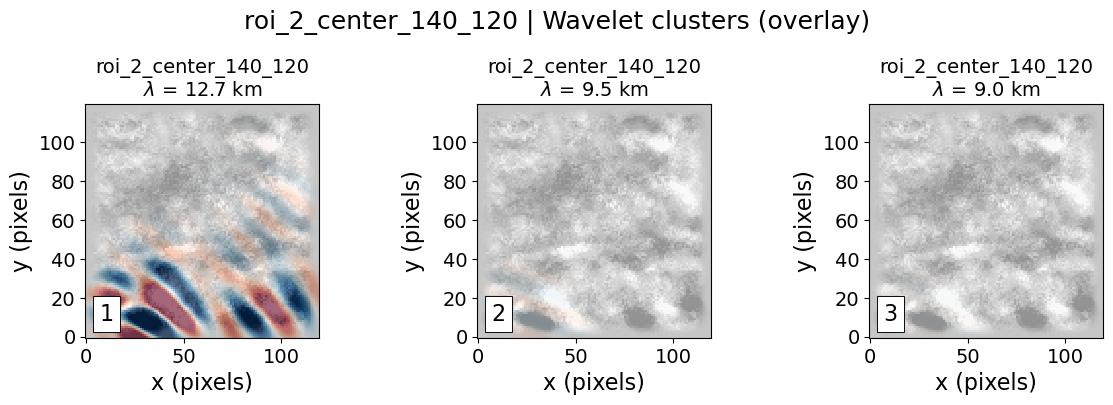

In [2]:
# Full TIFF -> MULTI-ROI -> background removal -> wavelet clusters
#
# For each ROI in ROI_SETS, produces:
#   1) Full TIFF preview (mean ± SIGMA_FACTOR*sigma) with ALL ROI rectangles
#   2) 4-panel background figure (orig/bg/remaining/taper+despike)
#   3) Wavelet decomposition summary (utils.plot_decomposition2d)
#   4) FOV wavelet spectrum (orientation vs wavelength)
#   5) Standalone wavelet clusters (up to N_CLUSTERS_SHOW)
#   6) Overlay clusters on top of tapered remaining field (up to N_CLUSTERS_SHOW)
#
# Notes:
#   - The clip range (lo/hi) is computed ONCE from the full image and reused for all ROIs.
#   - Each ROI run is independent and prints its own summaries.

from __future__ import annotations
from typing import Tuple, Optional, List

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import tifffile as tiff

from scipy.ndimage import median_filter
from juwavelet import transform, utils, plot_utils
from pathlib import Path

# --------------------
# User settings
# --------------------
TIFF_PATH = Path().resolve() / r"Sep15-16(2025)\TempOH_caun0504.tif"
#"C:\Users\domin\juwavelet\Bear Lake Phase Speed Comparison Notebooks\Sep 13 2025\BandOH_caun0571.tif"

# ---- MULTIPLE ROIs ----
# Each tuple: (name, X_SLICE, Y_SLICE)
ROI_SETS = [
    #("roi_1_center_200_150", slice(140, 260), slice(90, 210)),
    #("roi_2_center_110_120", slice(50, 170), slice(60, 180)),
    ("roi_2_center_140_120", slice(80, 200), slice(60, 180)),
    # Add more as needed
]

# Single sigma factor: mean ± 0.5σ (computed once on full image)
SIGMA_FACTOR = 0.4

# Preprocessing / background
REMOVE_TREND = True         # include 2D plane in "background"
STANDARDIZE = True          # z-score like scaling before CWT
GAUSS_BLUR_SIGMA = 0        # 0 disables, else e.g. 0.8

# Edge taper on remaining field (before CWT)
APPLY_TAPER = True
TAPER_EDGE_PIXELS = 10      # width of tapered region near each edge (pixels)

# Despike options (applied after tapering, before CWT)
APPLY_DESPIKE = True
DESPIKE_SIZE = 5            # median window size (odd integer)
DESPIKE_K = 2.0             # threshold in local "sigma" units

# Wavelet params
S0 = 8
DJ = 1 / 12
JS = 24
JT = 36
ASPECT = 1

# Pixel spacing (km/pixel) for CWT (wavelengths will be in km)
DX = 0.623
DY = 0.623

# Cluster identification parameters
CLUSTER_MIN_AMP = 0.25      # min_amp for identify_cluster2d
CLUSTER_THR = 0.2           # thr for identify_cluster2d

# How many clusters to show in the summary figures
N_CLUSTERS_SHOW = 3

# --------------------------
# Plot style
# --------------------------
matplotlib.rcParams.update({
    "axes.labelsize": 16,
    "font.size": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 14,
    "figure.figsize": [2 * 6.94, 2 * 4.29],
})

# --------------------------
# Helpers
# --------------------------
def load_tiff(path: str | Path) -> np.ndarray:
    """Load single-frame 2D TIFF as float32 array."""
    img = tiff.imread(str(path))
    if img.ndim == 3 and img.shape[-1] == 1:
        img = img[..., 0]
    if img.ndim != 2:
        raise ValueError(f"Expected single-frame 2D TIFF; got shape {img.shape}")
    Z = np.asarray(img, dtype=np.float32)
    med = float(np.median(Z))
    Z = np.nan_to_num(Z, nan=med, posinf=med, neginf=med).astype(np.float32, copy=False)
    return Z


def fit_plane(Z: np.ndarray) -> np.ndarray:
    """Fit a 2D plane ax + by + c to Z (least squares) and return the plane."""
    ny, nx = Z.shape
    yy, xx = np.mgrid[0:ny, 0:nx]
    G = np.stack([xx.ravel(), yy.ravel(), np.ones(nx * ny)], axis=1)
    coeff, *_ = np.linalg.lstsq(G, Z.ravel(), rcond=None)
    return (coeff[0] * xx + coeff[1] * yy + coeff[2])


def extract_first_fourier_bg(Z: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    Keep only the first Fourier components in x and y:
      - fundamental in x: kx = ±1, ky = 0
      - fundamental in y: ky = ±1, kx = 0
    Returns (background_from_fft, residual).
    """
    ny, nx = Z.shape
    F = np.fft.fft2(Z)
    F_bg = np.zeros_like(F, dtype=complex)

    if nx > 1:
        F_bg[0, 1] = F[0, 1]
        F_bg[0, -1] = F[0, -1]

    if ny > 1:
        F_bg[1, 0] = F[1, 0]
        F_bg[-1, 0] = F[-1, 0]

    bg = np.fft.ifft2(F_bg).real
    resid = Z - bg
    return bg, resid


def maybe_blur(Z: np.ndarray, sigma: float) -> np.ndarray:
    if sigma <= 0:
        return Z
    try:
        from scipy.ndimage import gaussian_filter
    except Exception:
        return Z
    return gaussian_filter(Z, sigma=float(sigma))


def _fmt(v: float) -> str:
    if not np.isfinite(v):
        return "∞"
    v = float(v)
    if abs(v) >= 1000 or abs(v) < 0.1:
        return f"{v:.2e}"
    elif abs(v) >= 100:
        return f"{v:.0f}"
    else:
        return f"{v:.1f}"


def despike_local_sigma(Z: np.ndarray, size: int = 3, k: float = 5.0) -> np.ndarray:
    """Replace pixels that deviate too much from a local median (MAD-based)."""
    Z = np.asarray(Z, float)
    med = median_filter(Z, size=size)
    mad = median_filter(np.abs(Z - med), size=size)
    mad = np.where(mad == 0, np.nan, mad)
    mask_spike = np.abs(Z - med) > k * mad
    Z_clean = Z.copy()
    Z_clean[mask_spike] = med[mask_spike]
    return Z_clean


def _hanning_edge_1d(n: int, edge: int) -> np.ndarray:
    """1D window: ramps from 0 at edges to 1 over `edge` pixels, 1 in interior."""
    w = np.ones(n, dtype=float)
    if edge <= 0:
        return w
    edge = min(edge, n // 2)
    ramp = 0.5 * (1.0 - np.cos(np.linspace(0, np.pi, edge, endpoint=True)))
    w[:edge] = ramp
    w[-edge:] = ramp[::-1]
    return w


def apply_edge_hanning_taper(Z: np.ndarray, edge: int) -> np.ndarray:
    """Apply separable 2D edge taper (Hanning-like) near boundaries."""
    ny, nx = Z.shape
    if edge <= 0:
        return Z
    wx = _hanning_edge_1d(nx, edge)
    wy = _hanning_edge_1d(ny, edge)
    W = np.outer(wy, wx)
    return Z * W


def _slice_bounds(s: Optional[slice], n: int) -> Tuple[int, int]:
    """Convert slice into [start, stop) bounds with defaults."""
    if s is None:
        return 0, n
    start = 0 if s.start is None else int(s.start)
    stop = n if s.stop is None else int(s.stop)
    return start, stop


# --------------------------
# Full-image preview with ALL ROIs
# --------------------------
def plot_full_preview_with_rois(full: np.ndarray, lo: float, hi: float, roi_sets):
    ny_full, nx_full = full.shape
    x_full = np.arange(nx_full, dtype=float)
    y_full = np.arange(ny_full, dtype=float)
    y_full_flip = y_full[::-1]

    disp_prev = np.clip(full.astype(float), lo, hi)

    fig_prev, ax_prev = plt.subplots()
    im_prev = ax_prev.pcolormesh(
        x_full, y_full_flip, disp_prev,
        shading="auto", cmap="gray", vmin=lo, vmax=hi
    )
    cb_prev = fig_prev.colorbar(im_prev, ax=ax_prev, fraction=0.046, pad=0.04)
    cb_prev.set_label("Intensity (a.u.)")

    ax_prev.set_xlabel("x (pixels)")
    ax_prev.set_ylabel("y (pixels)")
    ax_prev.set_aspect("equal", adjustable="box")
    ax_prev.set_title(f"Full TIFF clipped to mean ± {SIGMA_FACTOR:.2f}σ (all ROIs)")

    colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

    for i, (name, xsl, ysl) in enumerate(roi_sets):
        x0, x1 = _slice_bounds(xsl, nx_full)
        y0, y1 = _slice_bounds(ysl, ny_full)

        # Map ROI y-range to flipped-y display coords
        y0_disp = ny_full - y1
        y1_disp = ny_full - y0

        rect = patches.Rectangle(
            (x0, y0_disp), x1 - x0, y1_disp - y0_disp,
            linewidth=2, edgecolor=colors[i % len(colors)], facecolor="none"
        )
        ax_prev.add_patch(rect)

        ax_prev.text(
            x0 + 2, y0_disp + 2, name,
            color=colors[i % len(colors)], fontsize=11,
            va="bottom", ha="left",
            bbox=dict(boxstyle="round,pad=0.2", facecolor="white", edgecolor="none", alpha=0.75)
        )

    plt.tight_layout()
    plt.show(fig_prev)


# --------------------------
# Per-ROI pipeline
# --------------------------
def run_one_roi(full: np.ndarray, lo: float, hi: float, roi_name: str,
                x_slice: Optional[slice], y_slice: Optional[slice]) -> None:

    ny_full, nx_full = full.shape
    ysl = y_slice if y_slice is not None else slice(None, None)
    xsl = x_slice if x_slice is not None else slice(None, None)

    raw = full[ysl, xsl].astype(float)
    ny, nx = raw.shape
    x1d = np.arange(nx, dtype=float)
    y1d = np.arange(ny, dtype=float)[::-1]  # flip y for display

    print("\n" + "=" * 80)
    print(f"[ROI: {roi_name}] shape: {raw.shape}   X={x_slice}   Y={y_slice}")

    # Clip ROI values to [lo, hi]
    proc0 = np.clip(raw, lo, hi)

    vals_roi = proc0.ravel()
    if vals_roi.size > 0:
        print(f"[ROI: {roi_name}] Count: {vals_roi.size}")
        print(f"[ROI: {roi_name}] Min/max after clip: {np.nanmin(vals_roi):.2f} / {np.nanmax(vals_roi):.2f}")
        p5r, p50r, p95r = np.nanpercentile(vals_roi, [5, 50, 95])
        print(f"[ROI: {roi_name}] Percentiles 5/50/95 (clipped): {p5r:.2f} / {p50r:.2f} / {p95r:.2f}")
    else:
        print(f"[ROI: {roi_name}] Warning: no pixels?")

    # Background separation: plane + first Fourier
    if REMOVE_TREND:
        plane = fit_plane(proc0)
        detrended = proc0 - plane
    else:
        plane = np.zeros_like(proc0)
        detrended = proc0

    fourier_bg, _ = extract_first_fourier_bg(detrended)
    background = plane + fourier_bg
    remaining = proc0 - background

    # Edge taper
    if APPLY_TAPER:
        remaining_tapered = apply_edge_hanning_taper(remaining, TAPER_EDGE_PIXELS)
    else:
        remaining_tapered = remaining.copy()

    # Despike after taper
    if APPLY_DESPIKE:
        remaining_tapered_clean = despike_local_sigma(
            remaining_tapered, size=DESPIKE_SIZE, k=DESPIKE_K
        )
    else:
        remaining_tapered_clean = remaining_tapered

    # Centered versions for plotting
    med0 = np.nanmedian(proc0)
    orig_c = proc0 - med0
    bg_c = background - med0
    rem_c = remaining
    rem_tapered_c = remaining_tapered_clean

    # Global color scale for 4-panel
    stacked = np.concatenate([orig_c.ravel(), bg_c.ravel(), rem_c.ravel(), rem_tapered_c.ravel()])
    p_low, p_high = np.nanpercentile(stacked, [1, 99])
    vmax = max(abs(p_low), abs(p_high))
    if vmax == 0 or not np.isfinite(vmax):
        vmax = 1.0
    vmin = -vmax

    # 4-panel background figure
    fig_bg, axs_bg = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
    axes_bg_flat = axs_bg.flatten()

    # Put ROI name once at the top to avoid title collisions
    fig_bg.suptitle(f"{roi_name} | Background removal", fontsize=18)

    imgs_bg = [
        (orig_c, "Original\n(median sub, clipped)"),
        (bg_c, "Background\n(plane + first Fourier)"),
        (rem_c, "Remaining\n(original − background)"),
        (rem_tapered_c, "Remaining\n(taper + despike)"),
    ]

    im_bg = None
    for ax, (Z, title) in zip(axes_bg_flat, imgs_bg):
        im_bg = ax.pcolormesh(
            x1d, y1d, Z,
            shading="auto",
            cmap="RdBu_r",
            vmin=vmin,
            vmax=vmax,
        )
        ax.set_title(title, fontsize=14, pad=6)
        ax.set_xlabel("x (pixels)")
        ax.set_ylabel("y (pixels)")
        ax.set_aspect("equal", adjustable="box")

    cbar_bg = fig_bg.colorbar(
        im_bg,
        ax=axs_bg,
        orientation="vertical",
        fraction=0.04,
        pad=0.02,
    )
    cbar_bg.set_label("Intensity (a.u.)")

    plt.show(fig_bg)

    # Preprocess for CWT only (standardize + blur)
    proc = remaining_tapered_clean.copy()
    if STANDARDIZE:
        m_proc = np.median(proc)
        proc = proc - m_proc
        s_proc = np.std(proc)
        proc = proc / s_proc if s_proc > 0 else proc
    proc = maybe_blur(proc, GAUSS_BLUR_SIGMA)

    # juwavelet expects (nx, ny); image is (ny, nx)
    wave_xy = proc.T

    cwt = transform.decompose2d(
        wave_xy, dx=DX, dy=DY, s0=S0, dj=DJ, js=JS, jt=JT, aspect=ASPECT
    )

    # Identify clusters
    amps, idxs, iwave = utils.identify_cluster2d(
        cwt, min_amp=CLUSTER_MIN_AMP, thr=CLUSTER_THR
    )

    decomposition = cwt["decomposition"]
    orig_decomp = decomposition.copy()

    # Overview CWT plot
    cmap_cwt = matplotlib.cm.turbo
    norm_cwt = matplotlib.colors.BoundaryNorm(
        np.exp(np.linspace(np.log(0.05), np.log(1.0), 10)), cmap_cwt.N
    )
    fig_cwt, _ = utils.plot_decomposition2d(
        cwt, redux_s=8, redux_t=4, cmap=cmap_cwt, norm=norm_cwt
    )
    fig_cwt.suptitle(f"{roi_name} | Wavelet decomposition", y=1.02)
    plt.show(fig_cwt)

    # FOV wavelet spectrum
    plot_utils.plot_fov_wavelet_spectrum(cwt, stat="max")
    plt.gcf().suptitle(f"{roi_name} | FOV wavelet spectrum", y=1.02)
    plt.show()

    # Background image for overlays: tapered remaining (spikes removed), centered
    bg_tapered_centered = remaining_tapered_clean - np.median(remaining_tapered_clean)
    bg_low, bg_high = np.nanpercentile(bg_tapered_centered, [2, 98])
    bg_vmax = max(abs(bg_low), abs(bg_high))
    if not np.isfinite(bg_vmax) or bg_vmax == 0:
        bg_vmax = 1.0
    bg_vmin = -bg_vmax

    # Common style for numbering panels
    number_box = {"boxstyle": "square", "lw": 0.67, "facecolor": "white", "edgecolor": "black"}

    # -------------------------------------------------
    # Figure 1: standalone clusters
    # -------------------------------------------------
    fig1, axs1 = plt.subplots(1, N_CLUSTERS_SHOW, figsize=(4 * N_CLUSTERS_SHOW, 4))
    axes1_flat = np.atleast_1d(axs1).ravel()

    fig1.suptitle(f"{roi_name} | Wavelet clusters (standalone)", fontsize=18)

    opts_img_cluster = {
        "cmap": "RdBu_r",
        "vmin": -0.8,
        "vmax": 0.8,
        "rasterized": True,
    }

    n_clusters = len(amps) if amps is not None else 0

    if n_clusters == 0:
        for ax in axes1_flat:
            ax.set_title("No clusters found")
            ax.axis("off")
    else:
        order = np.argsort(amps)[::-1]
        n_show = min(N_CLUSTERS_SHOW, n_clusters)
        biggest = order[:n_show]

        for ax, kcl in zip(axes1_flat[:n_show], biggest):
            decomposition[:] = orig_decomp
            decomposition[iwave != kcl] = 0

            rec = transform.reconstruct2d(cwt)   # (nx, ny)
            rec_centered = rec.T - np.median(rec)

            udx = idxs[kcl]
            s_idx = int(udx[0])
            t_idx = int(udx[1])

            lamx = cwt["wavelength_x"][s_idx, t_idx]
            lamy = cwt["wavelength_y"][s_idx, t_idx]

            inv2 = 0.0
            if np.isfinite(lamx) and lamx != 0:
                inv2 += (1.0 / lamx) ** 2
            if np.isfinite(lamy) and lamy != 0:
                inv2 += (1.0 / lamy) ** 2

            lam = np.inf if inv2 == 0 else 1.0 / np.sqrt(inv2)

            ax.set_title(
                rf"{roi_name}" + "\n" + rf"$\lambda$ = {_fmt(lam)} km",
                fontsize=14,
            )

            ax.pcolormesh(x1d, y1d, rec_centered, **opts_img_cluster)
            ax.set_aspect("equal", adjustable="box")

            # mark peak
            decomposition[:] = np.abs(decomposition)
            max_idx = np.unravel_index(
                decomposition[s_idx, t_idx].argmax(),
                decomposition[0, 0].shape,
            )
            ax.plot(x1d[max_idx[0]], y1d[max_idx[1]], "o",
                    color="w", mec="k", ms=8)

        for ax in axes1_flat[n_show:]:
            ax.axis("off")

    for i, ax in enumerate(axes1_flat, start=1):
        ax.set_xlabel("x (pixels)")
        ax.set_ylabel("y (pixels)")
        ax.text(
            0.12, 0.15, str(i),
            transform=ax.transAxes,
            bbox=number_box,
            va="top",
            ha="right",
        )

    fig1.tight_layout()
    plt.show(fig1)

    # -------------------------------------------------
    # Figure 2: overlays
    # -------------------------------------------------
    fig2, axs2 = plt.subplots(1, N_CLUSTERS_SHOW, figsize=(4 * N_CLUSTERS_SHOW, 4))
    axes2_flat = np.atleast_1d(axs2).ravel()

    fig2.suptitle(f"{roi_name} | Wavelet clusters (overlay)", fontsize=18)

    if n_clusters == 0:
        for ax in axes2_flat:
            ax.set_title("No clusters found")
            ax.axis("off")
    else:
        cl_vmin, cl_vmax = -0.6, 0.6
        order = np.argsort(amps)[::-1]
        n_show = min(N_CLUSTERS_SHOW, n_clusters)
        biggest = order[:n_show]

        for ax, kcl in zip(axes2_flat[:n_show], biggest):
            ax.pcolormesh(
                x1d, y1d, bg_tapered_centered,
                shading="auto",
                cmap="gray",
                vmin=bg_vmin,
                vmax=bg_vmax,
            )

            decomposition[:] = orig_decomp
            decomposition[iwave != kcl] = 0
            rec = transform.reconstruct2d(cwt)
            rec_centered = rec.T - np.median(rec)

            udx = idxs[kcl]
            s_idx = int(udx[0])
            t_idx = int(udx[1])

            lamx = cwt["wavelength_x"][s_idx, t_idx]
            lamy = cwt["wavelength_y"][s_idx, t_idx]

            inv2 = 0.0
            if np.isfinite(lamx) and lamx != 0:
                inv2 += (1.0 / lamx) ** 2
            if np.isfinite(lamy) and lamy != 0:
                inv2 += (1.0 / lamy) ** 2

            lam = np.inf if inv2 == 0 else 1.0 / np.sqrt(inv2)

            ax.pcolormesh(
                x1d, y1d, rec_centered,
                shading="auto",
                cmap="RdBu_r",
                vmin=cl_vmin,
                vmax=cl_vmax,
                alpha=0.6,
            )

            ax.set_title(
                rf"{roi_name}" + "\n" + rf"$\lambda$ = {_fmt(lam)} km",
                fontsize=14,
            )
            ax.set_aspect("equal", adjustable="box")

        for ax in axes2_flat[n_show:]:
            ax.axis("off")

    for i, ax in enumerate(axes2_flat, start=1):
        ax.set_xlabel("x (pixels)")
        ax.set_ylabel("y (pixels)")
        ax.text(
            0.12, 0.15, str(i),
            transform=ax.transAxes,
            bbox=number_box,
            va="top",
            ha="right",
        )

    fig2.tight_layout()
    plt.show(fig2)

# --------------------------
# Run (multi-ROI)
# --------------------------
def run_pipeline_multi_roi():
    # Load full TIFF once
    full = load_tiff(TIFF_PATH)

    # Compute mean/std once on full image for consistent clip
    sample_full = full.ravel().astype(float)
    center = float(np.mean(sample_full))
    sigma = float(np.std(sample_full))
    k = SIGMA_FACTOR
    lo = center - k * sigma
    hi = center + k * sigma

    print(f"[Full] mean: {center:.2f}")
    print(f"[Full] sigma: {sigma:.2f}")
    print(f"[Full] Clip range: [{lo:.2f}, {hi:.2f}] = mean ± {k:.2f}·sigma")

    # Full-image preview with ALL ROIs drawn
    plot_full_preview_with_rois(full, lo, hi, ROI_SETS)

    # Run each ROI
    for roi_name, xsl, ysl in ROI_SETS:
        run_one_roi(full, lo, hi, roi_name, xsl, ysl)


if __name__ == "__main__":
    run_pipeline_multi_roi()


## Save Crest Relative Amplitude Evolution

Found 11 TIFF files in C:\Users\domin\juwavelet\Bear Lake Phase Speed Comparison Notebooks\Sep16-17(2025)
Overlay base directory: C:\Users\domin\juwavelet\Bear Lake Phase Speed Comparison Notebooks\Sep16-17(2025)\overlays_crests_phase

=== ROI: roi_2_center_140_120 | X=slice(80, 200, None) | Y=slice(60, 180, None) ===


C:\Users\domin\juwavelet\juwavelet\transform.py:324: RuntimeWarning: divide by zero encountered in divide
  wys = periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :]))
C:\Users\domin\juwavelet\juwavelet\transform.py:367: RuntimeWarning: divide by zero encountered in divide
  "wavelength_y": periods[:, np.newaxis] / (aspect * np.sin(thetas[np.newaxis, :])),


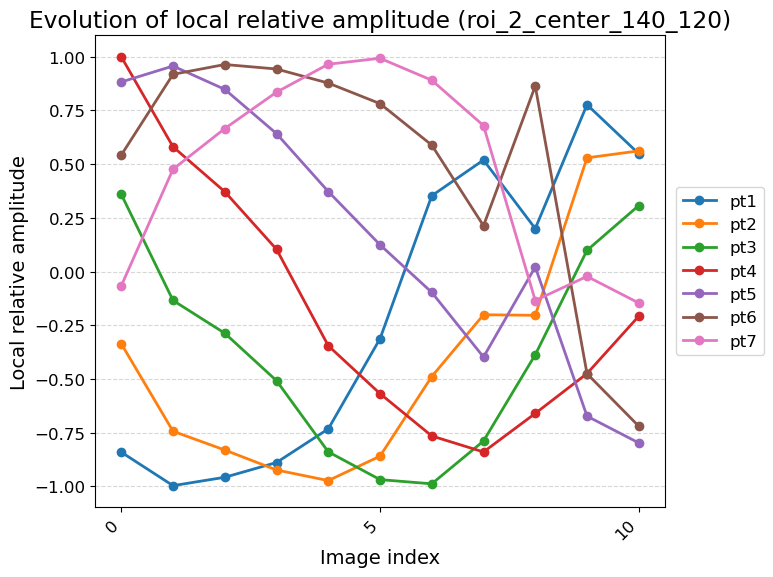

In [6]:
# %%
# Full (sliced) TIFF -> ROI -> background removal -> wavelet clusters
# (batch version, with crest marker + ridge line + relative-amplitude panel)
#
# MULTI-ROI VERSION:
#   - Define many ROIs in ROI_SETS
#   - Runs the same pipeline for each ROI
#   - Saves each ROI run into its own subfolder so nothing overwrites
#
# Updates requested:
#   - When saving the CSV, do NOT save NPY
#   - Also save the wavelength (km) for that image (one value per frame)

from __future__ import annotations
from typing import Tuple, Optional, List

from pathlib import Path
import csv

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import tifffile as tiff

from scipy.ndimage import median_filter, maximum_filter, minimum_filter
from scipy import ndimage
from skimage import morphology

from juwavelet import transform, utils


def _silent_print(*args, **kwargs):
    pass

# Silence juwavelet's internal prints (as in PNG cell)
utils.print = _silent_print

# --------------------------
# User params
# --------------------------

# Folder with input TIFFs
TIFF_DIR = Path().resolve() / "Sep16-17(2025)"# / "BLO10369"

# Optional explicit output folder for overlays
# If None, a subfolder "overlays_crests_phase" will be created inside TIFF_DIR
OVERLAY_DIR: Optional[str] = None

# ---- MULTIPLE ROIs ----
# Each tuple: (name, X_SLICE, Y_SLICE)
#ROI_SETS = [
#    
#]

# Single sigma factor: mean ± 0.5σ (computed once on full image)
SIGMA_FACTOR = 0.5

# Preprocessing / background
REMOVE_TREND = True         # include 2D plane in "background"
STANDARDIZE = True          # z-score like scaling before CWT
GAUSS_BLUR_SIGMA = 0        # 0 disables, else e.g. 0.8

# Edge taper on remaining field (before CWT)
APPLY_TAPER = True
TAPER_EDGE_PIXELS = 10      # width of tapered region near each edge (pixels)

# Despike options (you can set to False if you want EXACT PNG behaviour)
APPLY_DESPIKE = True
DESPIKE_SIZE = 5            # median window size (odd integer)
DESPIKE_K = 2.0             # threshold in local "sigma" units

# Wavelet params
S0 = 8
DJ = 1/12
JS = 24
JT = 36
ASPECT = 1

# Pixel spacing (km/pixel) for CWT (wavelengths will be in km)
DX = 0.623
DY = 0.623

# Cluster identification parameters
CLUSTER_MIN_AMP = 0.25      # min_amp for identify_cluster2d
CLUSTER_THR = 0.1           # thr for identify_cluster2d

# Band-pass filter on effective wavelength λ (km)
ENABLE_BANDPASS = False
BANDPASS_LMIN_KM = 8.0
BANDPASS_LMAX_KM = 16.0

# Angle filter on wave-vector direction (degrees)
ENABLE_ANGLE_FILTER = True
ANGLE_MIN_DEG = 120.0
ANGLE_MAX_DEG = 180.0

# Cluster plotting controls
MAX_CLUSTERS = 1             # maximum number of clusters to show per TIFF

# Crest detection parameters (only 1 crest, like PNG script)
CREST_NEIGHBORHOOD = 7
CREST_MIN_RELAMP = 0.2
CRESTS_PER_CLUSTER = 1       # ONLY FIRST CREST

# Tracking params (same as PNG script)
N_SAMPLE_POINTS = 7          # crest + 3 on each side

# Plot controls
SHOW_FIGS = False
SAVE_OVERLAY = True

# Verbosity
VERBOSE = False               # Set to True if you want prints

# --------------------------
# Plot style
# --------------------------
matplotlib.rcParams.update({
    "axes.labelsize": 14,
    "font.size": 14,
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
    "legend.fontsize": 12,
    "figure.figsize": [12, 8],
})

# --------------------------
# Small logger
# --------------------------
def log(msg: str) -> None:
    if VERBOSE:
        print(msg)

# --------------------------
# Helpers
# --------------------------
def load_tiff(path: str) -> np.ndarray:
    """Load single-frame 2D TIFF as float32 array."""
    img = tiff.imread(path)
    if img.ndim == 3 and img.shape[-1] == 1:
        img = img[..., 0]
    if img.ndim != 2:
        raise ValueError(f"Expected single-frame 2D TIFF; got shape {img.shape}")
    Z = np.asarray(img, dtype=np.float32)
    med = float(np.median(Z))
    Z = np.nan_to_num(Z, nan=med, posinf=med, neginf=med).astype(np.float32, copy=False)
    return Z


def fit_plane(Z: np.ndarray) -> np.ndarray:
    """Fit a 2D plane ax + by + c to Z (least squares) and return the plane."""
    ny, nx = Z.shape
    yy, xx = np.mgrid[0:ny, 0:nx]
    G = np.stack([xx.ravel(), yy.ravel(), np.ones(nx * ny)], axis=1)
    coeff, *_ = np.linalg.lstsq(G, Z.ravel(), rcond=None)
    plane = (coeff[0] * xx + coeff[1] * yy + coeff[2])
    return plane


def extract_first_fourier_bg(Z: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
    """
    From a 2D field Z, keep only the first Fourier components in x and y:
      - fundamental in x: kx = ±1, ky = 0
      - fundamental in y: ky = ±1, kx = 0
    Returns (background_from_fft, residual).
    """
    ny, nx = Z.shape
    F = np.fft.fft2(Z)
    F_bg = np.zeros_like(F, dtype=complex)

    # fundamental in x (along columns, ky = 0)
    if nx > 1:
        F_bg[0, 1] = F[0, 1]
        F_bg[0, -1] = F[0, -1]

    # fundamental in y (along rows, kx = 0)
    if ny > 1:
        F_bg[1, 0] = F[1, 0]
        F_bg[-1, 0] = F[-1, 0]

    bg = np.fft.ifft2(F_bg).real
    resid = Z - bg
    return bg, resid


def maybe_blur(Z: np.ndarray, sigma: float) -> np.ndarray:
    if sigma <= 0:
        return Z
    try:
        from scipy.ndimage import gaussian_filter
    except Exception:
        return Z
    return gaussian_filter(Z, sigma=float(sigma))


def _fmt(v: float) -> str:
    if not np.isfinite(v):
        return "∞"
    v = float(v)
    if abs(v) >= 1000 or abs(v) < 0.1:
        return f"{v:.2e}"
    elif abs(v) >= 100:
        return f"{v:.0f}"
    else:
        return f"{v:.1f}"


def despike_local_sigma(Z: np.ndarray, size: int = 3, k: float = 5.0) -> np.ndarray:
    """Replace pixels that deviate too much from a local median."""
    Z = np.asarray(Z, float)
    med = median_filter(Z, size=size)
    mad = median_filter(np.abs(Z - med), size=size)
    mad = np.where(mad == 0, np.nan, mad)

    mask_spike = np.abs(Z - med) > k * mad
    Z_clean = Z.copy()
    Z_clean[mask_spike] = med[mask_spike]
    return Z_clean


# --------------------------
# Edge taper (Hanning near boundaries)
# --------------------------
def _hanning_edge_1d(n: int, edge: int) -> np.ndarray:
    """1D window that ramps to 1 over `edge` pixels and equals 1 in the interior."""
    w = np.ones(n, dtype=float)
    if edge <= 0:
        return w
    edge = min(edge, n // 2)
    ramp = 0.5 * (1.0 - np.cos(np.linspace(0, np.pi, edge, endpoint=True)))
    w[:edge] = ramp
    w[-edge:] = ramp[::-1]
    return w


def apply_edge_hanning_taper(Z: np.ndarray, edge: int) -> np.ndarray:
    """Apply a separable 2D Hanning-like taper only near edges."""
    ny, nx = Z.shape
    if edge <= 0:
        return Z
    wx = _hanning_edge_1d(nx, edge)
    wy = _hanning_edge_1d(ny, edge)
    W = np.outer(wy, wx)
    return Z * W


# --------------------------
# Helpers for λ and angle
# --------------------------
def compute_lambda_theta_fields(cwt: dict) -> Tuple[np.ndarray, np.ndarray]:
    """
    Compute effective wavelength λ (km) and angle θ (deg) for all (s, t).
    λ: 1/λ² = 1/λx² + 1/λy²
    θ: atan2(ky, kx) -> [0, 180)
    """
    lamx = np.asarray(cwt["wavelength_x"], float)
    lamy = np.asarray(cwt["wavelength_y"], float)

    with np.errstate(divide="ignore", invalid="ignore"):
        inv_lamx2 = np.where(np.isfinite(lamx) & (lamx != 0.0), 1.0 / (lamx**2), 0.0)
        inv_lamy2 = np.where(np.isfinite(lamy) & (lamy != 0.0), 1.0 / (lamy**2), 0.0)
        inv2 = inv_lamx2 + inv_lamy2
        lam_eff = np.where(inv2 > 0, 1.0 / np.sqrt(inv2), np.inf)

        kx = np.where(np.isfinite(lamx) & (lamx != 0.0), 1.0 / lamx, 0.0)
        ky = np.where(np.isfinite(lamy) & (lamy != 0.0), 1.0 / lamy, 0.0)

        theta_deg = np.degrees(np.arctan2(ky, kx))
        theta_deg = np.mod(theta_deg, 180.0)

    return lam_eff, theta_deg


def compute_cluster_lambda_and_angle(cwt: dict, idx_s: int, idx_t: int) -> Tuple[float, float]:
    lam_eff, theta_deg = compute_lambda_theta_fields(cwt)
    lam = float(lam_eff[idx_s, idx_t])
    theta = float(theta_deg[idx_s, idx_t])
    return lam, theta


# --------------------------
# Crest detection (only 1 crest)
# --------------------------
def find_top_crests(
    Z: np.ndarray,
    num: int = 1,
    neighborhood: int = 7,
    min_rel_amp: float = 0.2,
) -> List[Tuple[int, int, float]]:
    """Find up to `num` strongest local crests (positive local maxima) in Z."""
    Z = np.asarray(Z, float)
    if Z.size == 0:
        return []

    max_val = np.nanmax(Z)
    if not np.isfinite(max_val) or max_val <= 0:
        return []

    neighborhood = max(int(neighborhood), 1)

    local_max = maximum_filter(Z, size=neighborhood, mode="nearest")
    mask = (Z == local_max) & (Z > 0) & (Z >= min_rel_amp * max_val)

    ys, xs = np.where(mask)
    if ys.size == 0:
        iy, ix = np.unravel_index(np.nanargmax(Z), Z.shape)
        return [(int(iy), int(ix), float(Z[iy, ix]))][:num]

    vals = Z[ys, xs]
    order = np.argsort(vals)[::-1]

    crests: List[Tuple[int, int, float]] = []
    for idx in order[:num]:
        crests.append((int(ys[idx]), int(xs[idx]), float(vals[idx])))

    return crests


# --------------------------
# Ridge line (skeleton) along the bright band
# --------------------------
def compute_ridge_mask(Z: np.ndarray, level_frac: float = 0.6) -> np.ndarray:
    """Compute a 1-pixel-wide ridge mask for the dominant bright band in Z."""
    Z = np.asarray(Z, float)
    if Z.size == 0:
        return np.zeros_like(Z, dtype=bool)

    max_val = np.nanmax(Z)
    if not np.isfinite(max_val) or max_val <= 0:
        return np.zeros_like(Z, dtype=bool)

    level = level_frac * max_val
    mask = Z >= level
    if not np.any(mask):
        return np.zeros_like(Z, dtype=bool)

    labels, num = ndimage.label(mask)
    if num == 0:
        return np.zeros_like(Z, dtype=bool)

    iy_max, ix_max = np.unravel_index(np.nanargmax(Z), Z.shape)
    label_peak = labels[iy_max, ix_max]
    if label_peak == 0:
        return np.zeros_like(Z, dtype=bool)

    peak_comp = labels == label_peak
    ridge = morphology.skeletonize(peak_comp)
    return ridge


# --------------------------
# Single-file pipeline (NOW takes x_slice/y_slice)
# --------------------------
def run_pipeline_for_file(
    tiff_path: Path,
    overlay_dir: Path,
    show_figs: bool = False,
    save_overlay: bool = True,
    crest_iy: Optional[np.ndarray] = None,  # actually sample_iy (7 points)
    crest_ix: Optional[np.ndarray] = None,  # actually sample_ix (7 points)
    init_crests_from_this_file: bool = False,
    x_slice: Optional[slice] = None,
    y_slice: Optional[slice] = None,
) -> Tuple[Optional[np.ndarray], Optional[np.ndarray], Optional[np.ndarray], Optional[dict], float]:
    """
    Run the full pipeline on a single TIFF and optionally save the overlay figure.

    Returns
    -------
    vals_on_crests : 1D array of LOCAL RELATIVE AMPLITUDE at the 7 sample pixels
    crest_iy, crest_ix : 1D arrays of sample indices (row, col) from first TIFF (for this ROI)
    first_frame_info : dict with info for slice plot (only for first TIFF), or None
    lam_best_km_out : float, best effective wavelength (km) for the tracked cluster on this frame
    """
    log(f"\n=== Processing {tiff_path.name} ===")
    full = load_tiff(str(tiff_path))
    ny_full, nx_full = full.shape
    x_full = np.arange(nx_full, dtype=float)
    y_full = np.arange(ny_full, dtype=float)

    first_frame_info: Optional[dict] = None
    lam_best_km_out = np.nan

    # Compute mean/std once on the full image
    sample_full = full.ravel().astype(float)
    center = float(np.mean(sample_full))
    sigma = float(np.std(sample_full))
    k = SIGMA_FACTOR
    lo = center - k * sigma
    hi = center + k * sigma

    # Full preview (optional)
    if show_figs:
        preview = np.clip(full.astype(float), lo, hi)
        y_full_flip = y_full[::-1]

        fig_prev, ax_prev = plt.subplots()
        im_prev = ax_prev.pcolormesh(
            x_full,
            y_full_flip,
            preview,
            shading="auto",
            cmap="gray",
            vmin=lo,
            vmax=hi,
        )
        cb_prev = fig_prev.colorbar(im_prev, ax=ax_prev, fraction=0.046, pad=0.04)
        cb_prev.set_label("Intensity (a.u.)")
        ax_prev.set_xlabel("x (pixels)")
        ax_prev.set_ylabel("y (pixels)")
        ax_prev.set_title(f"{tiff_path.name}\nFull TIFF clipped to mean ± {k:.2f}σ")
        ax_prev.set_aspect("equal", adjustable="box")

        # ROI rectangle (uses x_slice/y_slice)
        ysl_full = y_slice if y_slice is not None else slice(0, ny_full)
        xsl_full = x_slice if x_slice is not None else slice(0, nx_full)

        x0 = 0 if xsl_full.start is None else xsl_full.start
        x1 = nx_full if xsl_full.stop is None else xsl_full.stop
        y0 = 0 if ysl_full.start is None else ysl_full.start
        y1 = ny_full if ysl_full.stop is None else ysl_full.stop

        y0_disp = ny_full - y1
        y1_disp = ny_full - y0

        rect = patches.Rectangle(
            (x0, y0_disp),
            x1 - x0,
            y1_disp - y0_disp,
            linewidth=2,
            edgecolor="red",
            facecolor="none",
        )
        ax_prev.add_patch(rect)

        plt.tight_layout()
        plt.show()

    # ROI (per-run slices)
    ysl = y_slice if y_slice is not None else slice(None, None)
    xsl = x_slice if x_slice is not None else slice(None, None)

    raw = full[ysl, xsl].astype(float)
    ny, nx = raw.shape
    x1d = np.arange(nx, dtype=float)
    y1d = np.arange(ny, dtype=float)[::-1]   # flipped for display

    # Clip ROI to mean ± 0.5σ
    proc0 = np.clip(raw, lo, hi)

    # Background separation: plane + first Fourier
    if REMOVE_TREND:
        plane = fit_plane(proc0)
        detrended = proc0 - plane
    else:
        plane = np.zeros_like(proc0)
        detrended = proc0

    fourier_bg, _ = extract_first_fourier_bg(detrended)
    background = plane + fourier_bg
    remaining = proc0 - background

    # Edge taper
    if APPLY_TAPER:
        remaining_tapered = apply_edge_hanning_taper(remaining, TAPER_EDGE_PIXELS)
    else:
        remaining_tapered = remaining.copy()

    # Despike
    if APPLY_DESPIKE:
        remaining_tapered_clean = despike_local_sigma(
            remaining_tapered, size=DESPIKE_SIZE, k=DESPIKE_K
        )
    else:
        remaining_tapered_clean = remaining_tapered

    # Centered versions for plotting
    med = np.nanmedian(proc0)
    orig_c = proc0 - med
    bg_c = background - med
    rem_c = remaining
    rem_tapered_c = remaining_tapered_clean

    # Optional background figure
    if show_figs:
        stacked = np.concatenate([orig_c.ravel(), bg_c.ravel(), rem_c.ravel(), rem_tapered_c.ravel()])
        p_low, p_high = np.nanpercentile(stacked, [1, 99])
        vmax = max(abs(p_low), abs(p_high))
        if vmax == 0 or not np.isfinite(vmax):
            vmax = 1.0
        vmin = -vmax

        fig_bg, axs_bg = plt.subplots(2, 2, figsize=(12, 10), constrained_layout=True)
        axes_bg_flat = axs_bg.flatten()

        imgs_bg = [
            (orig_c, "Original (median-sub, clipped)"),
            (bg_c, "Background (plane + first Fourier)"),
            (rem_c, "Remaining = original - background"),
            (rem_tapered_c, "Remaining with edge taper"),
        ]

        im_bg = None
        for ax, (Z, title) in zip(axes_bg_flat, imgs_bg):
            im_bg = ax.pcolormesh(x1d, y1d, Z, shading="auto", cmap="RdBu_r", vmin=vmin, vmax=vmax)
            ax.set_title(title)
            ax.set_xlabel("x (pixels)")
            ax.set_ylabel("y (pixels)")
            ax.set_aspect("equal")

        cbar_bg = fig_bg.colorbar(im_bg, ax=axs_bg, orientation="vertical", fraction=0.04, pad=0.02)
        cbar_bg.set_label("Intensity (a.u.)")
        plt.show()

    # Preprocess for CWT (standardize + blur)
    proc = remaining_tapered_clean.copy()
    if STANDARDIZE:
        m_proc = np.median(proc)
        proc = proc - m_proc
        s_proc = np.std(proc)
        proc = proc / s_proc if s_proc > 0 else proc
    proc = maybe_blur(proc, GAUSS_BLUR_SIGMA)

    # juwavelet expects (nx, ny); image is (ny, nx)
    wave_xy = proc.T

    cwt = transform.decompose2d(
        wave_xy, dx=DX, dy=DY, s0=S0, dj=DJ, js=JS, jt=JT, aspect=ASPECT
    )

    # Apply band-pass & angle filters BEFORE clustering
    decomposition = cwt["decomposition"]
    ns, nt, nx_cwt, ny_cwt = decomposition.shape

    lam_eff, theta_deg = compute_lambda_theta_fields(cwt)

    mask_keep = np.ones_like(lam_eff, dtype=bool)

    if ENABLE_BANDPASS:
        mask_keep &= (np.isfinite(lam_eff) & (lam_eff >= BANDPASS_LMIN_KM) & (lam_eff <= BANDPASS_LMAX_KM))

    if ENABLE_ANGLE_FILTER:
        mask_keep &= (np.isfinite(theta_deg) & (theta_deg >= ANGLE_MIN_DEG) & (theta_deg <= ANGLE_MAX_DEG))

    mask4 = mask_keep[:, :, None, None].astype(decomposition.dtype)
    decomposition *= mask4

    # Identify clusters
    amps, idxs, iwave = utils.identify_cluster2d(cwt, min_amp=CLUSTER_MIN_AMP, thr=CLUSTER_THR)
    orig_decomp = decomposition.copy()

    # Background for overlays
    bg_tapered_centered = remaining_tapered_clean - np.median(remaining_tapered_clean)
    bg_low, bg_high = np.nanpercentile(bg_tapered_centered, [2, 98])
    bg_vmax = max(abs(bg_low), abs(bg_high))
    if not np.isfinite(bg_vmax) or bg_vmax == 0:
        bg_vmax = 1.0
    bg_vmin = -bg_vmax

    n_clusters = len(amps) if amps is not None else 0

    crest_iy_out = crest_iy
    crest_ix_out = crest_ix
    vals_on_crests: Optional[np.ndarray] = None

    if n_clusters == 0:
        fig_empty, ax = plt.subplots(figsize=(6, 4))
        ax.pcolormesh(x1d, y1d, bg_tapered_centered, shading="auto", cmap="gray", vmin=bg_vmin, vmax=bg_vmax)
        ax.set_aspect("equal", adjustable="box")
        ax.set_xlabel("x (pixels)")
        ax.set_ylabel("y (pixels)")
        ax.set_title("No clusters after filters")
        fig_empty.tight_layout()

        if save_overlay:
            overlay_dir.mkdir(parents=True, exist_ok=True)
            out_path = overlay_dir / f"{tiff_path.stem}_overlay_clusters_crests_phase.png"
            fig_empty.savefig(out_path, dpi=200)

        if show_figs:
            plt.show(fig_empty)
        else:
            plt.close(fig_empty)

        return None, crest_iy_out, crest_ix_out, None, np.nan

    # Sort clusters by amplitude and limit to MAX_CLUSTERS
    order = np.argsort(amps)[::-1]
    n_show = min(n_clusters, MAX_CLUSTERS)

    fig, axes = plt.subplots(n_show, 3, figsize=(15, 4 * n_show), sharex=True, sharey=True)
    axes = np.atleast_2d(axes)

    for j in range(n_show):
        kcl = int(order[j])
        ax_bg = axes[j, 0]
        ax_ov = axes[j, 1]
        ax_ph = axes[j, 2]

        # LEFT: background
        ax_bg.pcolormesh(x1d, y1d, bg_tapered_centered, shading="auto", cmap="gray", vmin=bg_vmin, vmax=bg_vmax)
        ax_bg.set_title("Background (remaining_tapered_clean)")
        ax_bg.set_aspect("equal", adjustable="box")
        ax_bg.set_xlabel("x (pixels)")
        ax_bg.set_ylabel("y (pixels)")

        # MIDDLE: overlay (background + reconstruction)
        decomposition[:] = orig_decomp
        decomposition[iwave != kcl] = 0
        rec = transform.reconstruct2d(cwt)  # (nx, ny)
        rec_centered = rec.T - np.median(rec)  # (ny, nx)
        ny_img, nx_img = rec_centered.shape

        ax_ov.pcolormesh(x1d, y1d, bg_tapered_centered, shading="auto", cmap="gray", vmin=bg_vmin, vmax=bg_vmax)

        cl_vmin, cl_vmax = -0.6, 0.6
        ax_ov.pcolormesh(x1d, y1d, rec_centered, shading="auto", cmap="RdBu_r", vmin=cl_vmin, vmax=cl_vmax, alpha=0.6)

        # Ridge line
        ridge_mask = compute_ridge_mask(rec_centered, level_frac=0.6)
        if np.any(ridge_mask):
            ys_ridge, xs_ridge = np.where(ridge_mask)
            order_r = np.argsort(xs_ridge)
            xs_sorted = xs_ridge[order_r].astype(float)
            ys_sorted = ys_ridge[order_r].astype(float)
            x_disp_r = xs_sorted
            y_disp_r = ny_img - 1 - ys_sorted
            ax_ov.plot(x_disp_r, y_disp_r, linewidth=1.5, color="yellow")

        # Wavelength & angle (for title and direction)
        s_idx = int(idxs[kcl][0])
        t_idx = int(idxs[kcl][1])
        lam_best, theta_best = compute_cluster_lambda_and_angle(cwt, s_idx, t_idx)

        # Store wavelength for this frame (use the first shown cluster)
        if j == 0:
            lam_best_km_out = float(lam_best)

        ax_ov.set_title(f"Cluster {j+1} (id={kcl})\n" + rf"$\lambda$={_fmt(lam_best)}, $\theta$={theta_best:.1f}°")
        ax_ov.set_aspect("equal", adjustable="box")

        # RIGHT: local relative amplitude
        if np.isfinite(lam_best) and lam_best > 0:
            radius_km = lam_best / 2.0
            radius_pix = max(int(np.round(radius_km / DX)), 1)
        else:
            radius_pix = 1

        win_size = 2 * radius_pix + 1
        local_max = maximum_filter(rec_centered, size=win_size, mode="nearest")
        local_min = minimum_filter(rec_centered, size=win_size, mode="nearest")
        denom = local_max - local_min
        denom_safe = np.where(denom != 0, denom, np.nan)

        rel_amp = -1.0 + 2.0 * (rec_centered - local_min) / denom_safe
        rel_amp = np.where(np.isfinite(rel_amp), rel_amp, 0.0)
        rel_amp = np.clip(rel_amp, -1.0, 1.0)

        mask_cluster_xy = np.any(iwave == kcl, axis=(0, 1))   # (nx, ny)
        mask_cluster_img = mask_cluster_xy.T                  # (ny, nx)
        rel_amp_cluster = np.where(mask_cluster_img, rel_amp, np.nan)

        im_rel = ax_ph.pcolormesh(x1d, y1d, rel_amp_cluster, shading="auto", cmap="RdBu_r", vmin=-1.0, vmax=1.0)
        ax_ph.set_title(r"Local relative amplitude (radius $\lambda/2$)")
        ax_ph.set_aspect("equal", adjustable="box")
        ax_ph.set_xlabel("x (pixels)")
        ax_ph.set_ylabel("y (pixels)")

        cbar_ph = fig.colorbar(im_rel, ax=ax_ph, fraction=0.046, pad=0.04)
        cbar_ph.set_label("Relative amplitude")

        # Find ONLY 1 crest for visualization / tracking
        crests = find_top_crests(rec_centered, num=CRESTS_PER_CLUSTER, neighborhood=CREST_NEIGHBORHOOD, min_rel_amp=CREST_MIN_RELAMP)

        # Crest-based tracking (first cluster only)
        if j == 0:
            if init_crests_from_this_file and crest_iy_out is None and crest_ix_out is None:
                if len(crests) > 0:
                    crest0_iy, crest0_ix, _ = crests[0]

                    theta_rad = np.deg2rad(theta_best)
                    ux = np.cos(theta_rad)
                    uy = np.sin(theta_rad)

                    step_pix = max(radius_pix // 4, 1)

                    offsets = np.array([-3, -2, -1, 0, 1, 2, 3], dtype=float)
                    if offsets.size != N_SAMPLE_POINTS:
                        offsets = np.linspace(-3, 3, N_SAMPLE_POINTS)

                    sample_ix = crest0_ix + np.round(step_pix * offsets * ux).astype(int)
                    sample_iy = crest0_iy + np.round(step_pix * offsets * uy).astype(int)

                    # Optional per-point shifts (all zeros by default)
                    pixel_shifts = np.zeros(N_SAMPLE_POINTS, dtype=float)
                    for idx_pt, pix_shift in enumerate(pixel_shifts):
                        dx = int(np.round(pix_shift * ux))
                        dy = int(np.round(pix_shift * uy))
                        sample_ix[idx_pt] += dx
                        sample_iy[idx_pt] += dy

                    sample_ix = np.clip(sample_ix, 0, nx_img - 1)
                    sample_iy = np.clip(sample_iy, 0, ny_img - 1)

                    crest_ix_out = sample_ix
                    crest_iy_out = sample_iy

                    # Mark 7 sample points
                    for n_pt in range(N_SAMPLE_POINTS):
                        x_disp = float(crest_ix_out[n_pt])
                        y_disp = float(ny_img - 1 - crest_iy_out[n_pt])
                        ax_ov.plot(x_disp, y_disp, marker="o", markersize=4,
                                   markeredgecolor="magenta", markerfacecolor="magenta", markeredgewidth=0.8)
                        ax_ov.text(x_disp + 1.0, y_disp + 1.0, f"{n_pt+1}",
                                   color="cyan", fontsize=8, weight="bold")

            # Store info for first-frame slice plot
            if init_crests_from_this_file and crest_iy_out is not None and crest_ix_out is not None:
                first_frame_info = {
                    "rel_amp": rel_amp.copy(),
                    "crest_iy": crest_iy_out.copy(),
                    "crest_ix": crest_ix_out.copy(),
                }

            # Every frame: sample rel_amp at the 7 sample indices
            if crest_iy_out is not None and crest_ix_out is not None:
                if (crest_iy_out.max() < ny_img) and (crest_ix_out.max() < nx_img):
                    vals_on_crests = rel_amp[crest_iy_out, crest_ix_out]
                else:
                    vals_on_crests = None

    fig.suptitle(f"{tiff_path.name}", fontsize=16)
    fig.tight_layout(rect=[0, 0, 1, 0.96])

    if save_overlay:
        overlay_dir.mkdir(parents=True, exist_ok=True)
        out_path = overlay_dir / f"{tiff_path.stem}_overlay_clusters_crests_phase.png"
        fig.savefig(out_path, dpi=200)

    if show_figs:
        plt.show(fig)
    else:
        plt.close(fig)

    return vals_on_crests, crest_iy_out, crest_ix_out, first_frame_info, float(lam_best_km_out)


# --------------------------
# Batch driver (loops ROIs)
# --------------------------
def run_batch():
    tiff_dir = Path(TIFF_DIR)

    files = sorted(list(tiff_dir.glob("*.tif")) + list(tiff_dir.glob("*.tiff")))
    if not files:
        print(f"No TIFF files found in {tiff_dir}")
        return

    print(f"Found {len(files)} TIFF files in {tiff_dir}")

    # Base overlay folder
    if OVERLAY_DIR is not None:
        overlay_base = Path(OVERLAY_DIR)
    else:
        overlay_base = tiff_dir / "overlays_crests_phase"

    print(f"Overlay base directory: {overlay_base}")

    for roi_name, xsl, ysl in ROI_SETS:
        print(f"\n=== ROI: {roi_name} | X={xsl} | Y={ysl} ===")

        overlay_dir = overlay_base / roi_name
        overlay_dir.mkdir(parents=True, exist_ok=True)

        crest_iy = None
        crest_ix = None
        crest_value_series: List[np.ndarray] = []
        wavelength_series_km: List[float] = []
        frame_indices: List[int] = []
        first_frame_info: Optional[dict] = None

        for i, tiff_path in enumerate(files):
            vals_on_crests, crest_iy, crest_ix, first_info, lam_km = run_pipeline_for_file(
                tiff_path=tiff_path,
                overlay_dir=overlay_dir,
                show_figs=SHOW_FIGS,
                save_overlay=SAVE_OVERLAY,
                crest_iy=crest_iy,
                crest_ix=crest_ix,
                init_crests_from_this_file=(i == 0),
                x_slice=xsl,
                y_slice=ysl,
            )

            if first_frame_info is None and first_info is not None:
                first_frame_info = first_info

            if vals_on_crests is not None:
                crest_value_series.append(vals_on_crests)
                wavelength_series_km.append(float(lam_km))
                frame_indices.append(i)

        # Save + evolution plot for this ROI
        if crest_value_series:
            val_arr = np.vstack(crest_value_series)
            n_files_used, n_points = val_arr.shape
            frames = np.array(frame_indices, dtype=int)

            csv_path = overlay_dir / "crest_relative_amplitude_evolution.csv"
            with open(csv_path, "w", newline="") as f:
                writer = csv.writer(f)
                header = ["image_index", "wavelength_km"] + [f"pt{p+1}" for p in range(n_points)]
                writer.writerow(header)
                for irow in range(n_files_used):
                    writer.writerow([frames[irow], wavelength_series_km[irow]] + list(val_arr[irow, :]))

            # Evolution plot
            fig, ax = plt.subplots(figsize=(10, 6))
            for p in range(n_points):
                ax.plot(frames, val_arr[:, p], marker="o", linewidth=2, label=f"pt{p+1}")

            ax.set_xlabel("Image index")
            ax.set_ylabel("Local relative amplitude")
            ax.set_title(f"Evolution of local relative amplitude ({roi_name})")

            if len(frames) > 0:
                tick_positions = frames[::5]
                ax.set_xticks(tick_positions)
                ax.set_xticklabels(tick_positions, rotation=45, ha="right")
            else:
                ax.set_xticks([])
                ax.set_xticklabels([])

            ax.grid(True, axis="y", linestyle="--", alpha=0.5)
            ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), borderaxespad=0.0)
            plt.tight_layout(rect=[0, 0, 0.8, 1])
            plt.show()
        else:
            print(f"[{roi_name}] No amplitude data collected; skipping save/plot.")


if __name__ == "__main__":
    run_batch()


## Animation from pngs

In [7]:
# %%
# Make a movie (mp4) from the saved PNG overlays created by the batch cell.
#
# - Looks inside OVERLAY_BASE / <roi_name> for "*_overlay_clusters_crests_phase.png"
# - Writes one MP4 per ROI: "<roi_name>_overlay_clusters_crests_phase.mp4"
#
# Requirements:
#   pip/conda install imageio imageio-ffmpeg
# (If ffmpeg isn't found, see fallback notes in the error message.)

from __future__ import annotations
from pathlib import Path
import re

import imageio.v2 as imageio


# --------------------------
# Settings (edit these)
# --------------------------
FPS = 1  # frames per second

# If None: uses TIFF_DIR/"overlays_crests_phase" (same default as your batch code)
OVERLAY_BASE_DIR: Path | None = None

# If you only want some ROIs, list them here; otherwise leave as None to use ROI_SETS names
ONLY_ROIS: list[str] | None = None

# Match the overlay naming from your pipeline
PNG_GLOB = "*_overlay_clusters_crests_phase.png"

# Output format: "mp4" recommended (needs ffmpeg)
OUT_EXT = "mp4"   # "mp4" or "gif"


# --------------------------
# Helpers
# --------------------------
def _natural_key(p: Path):
    # Sort by any integer appearing in the filename (frame number), fallback to name
    nums = re.findall(r"\d+", p.stem)
    n0 = int(nums[0]) if nums else -1
    return (n0, p.name)


def make_movie_from_pngs(pngs: list[Path], out_path: Path, fps: int = 6) -> None:
    if not pngs:
        raise ValueError("No PNGs provided.")

    out_path.parent.mkdir(parents=True, exist_ok=True)

    if out_path.suffix.lower() == ".gif":
        with imageio.get_writer(out_path, mode="I", duration=1.0 / fps) as writer:
            for p in pngs:
                im = imageio.imread(p)
                writer.append_data(im)
        return

    # mp4
    try:
        with imageio.get_writer(out_path, fps=fps, codec="libx264", quality=8) as writer:
            for p in pngs:
                im = imageio.imread(p)
                writer.append_data(im)
    except Exception as e:
        raise RuntimeError(
            "Failed to write MP4. You likely need ffmpeg.\n"
            "Try:  conda install -c conda-forge ffmpeg  imageio-ffmpeg\n"
            "or:   pip install imageio-ffmpeg\n"
            f"Original error: {e}"
        )


# --------------------------
# Main
# --------------------------
# Use the same defaults as your batch pipeline
tiff_dir = Path(TIFF_DIR)
overlay_base = Path(OVERLAY_BASE_DIR) if OVERLAY_BASE_DIR is not None else (tiff_dir / "overlays_crests_phase")

# Determine ROI folders to process
roi_names = [r[0] for r in ROI_SETS]
if ONLY_ROIS is not None:
    roi_names = [r for r in roi_names if r in set(ONLY_ROIS)]

if not roi_names:
    raise ValueError("No ROI names found. Make sure ROI_SETS is defined and/or ONLY_ROIS is not empty.")

print("Overlay base:", overlay_base)
print("ROIs:", roi_names)
print("FPS:", FPS, "| Output:", OUT_EXT)

for roi in roi_names:
    roi_dir = overlay_base / roi
    if not roi_dir.exists():
        print(f"[skip] ROI folder not found: {roi_dir}")
        continue

    pngs = sorted(roi_dir.glob(PNG_GLOB), key=_natural_key)
    if not pngs:
        print(f"[skip] No PNGs found in: {roi_dir} (pattern: {PNG_GLOB})")
        continue

    out_path = roi_dir / f"{roi}_overlay_clusters_crests_phase.{OUT_EXT}"
    print(f"[write] {roi}: {len(pngs)} frames -> {out_path.name}")

    make_movie_from_pngs(pngs, out_path, fps=FPS)

print("Done.")


IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (3000, 800) to (3008, 800) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


Overlay base: C:\Users\domin\juwavelet\Bear Lake Phase Speed Comparison Notebooks\Sep16-17(2025)\overlays_crests_phase
ROIs: ['roi_2_center_140_120']
FPS: 1 | Output: mp4
[write] roi_2_center_140_120: 11 frames -> roi_2_center_140_120_overlay_clusters_crests_phase.mp4
Done.


## Analyze phase

Loading CSV from: C:\Users\domin\juwavelet\Bear Lake Phase Speed Comparison Notebooks\Sep16-17(2025)\overlays_crests_phase\roi_2_center_140_120\crest_relative_amplitude_evolution.csv
Detected columns:
  image_index -> image_index
  wavelength_km -> wavelength_km
  points -> ['pt1', 'pt2', 'pt3', 'pt4', 'pt5', 'pt6', 'pt7']
Data shape (frames, points): (11, 7)
Wavelength column loaded (km). Example stats: min=12.70, median=28.51, max=30.20
Initial a0 ≈ 36.000000 deg per frame

Best a from grid search (model y = cos(a t + b)):
  a_best ≈ 20.232000 deg per frame (initial 36.000000, factor 0.562)
  SSE_min = 3.3796


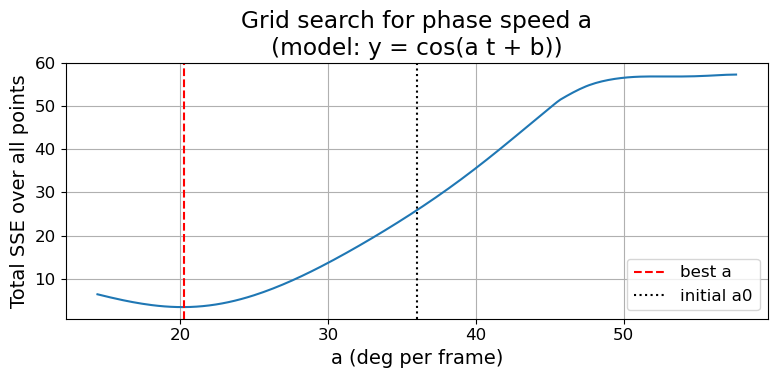


Per-point best phases (model y = cos(a t + b), A=1, C0=0):
  pt1: b ≈ 2.601 rad (149.0 deg), SSE=0.5675
  pt2: b ≈ 1.937 rad (111.0 deg), SSE=0.1372
  pt3: b ≈ 1.353 rad (77.5 deg), SSE=0.2322
  pt4: b ≈ 0.585 rad (33.5 deg), SSE=0.4659
  pt5: b ≈ 5.760 rad (330.0 deg), SSE=0.7345
  pt6: b ≈ 5.035 rad (288.5 deg), SSE=0.9646
  pt7: b ≈ 4.739 rad (271.5 deg), SSE=0.2776


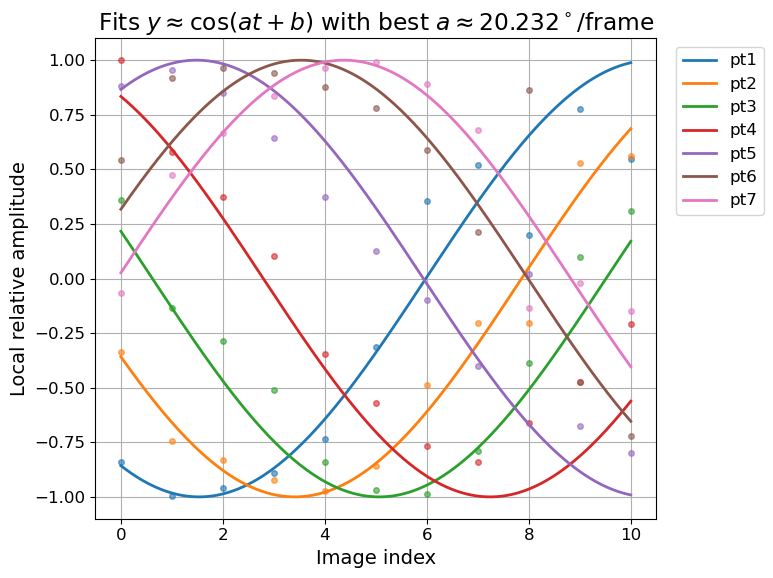

Direction = 1 (−1 means opposite propagation)
Phase shift per frame = 20.2320 deg
Frames = 11, steps = 10
Total phase span per curve ≈ 202.32 deg


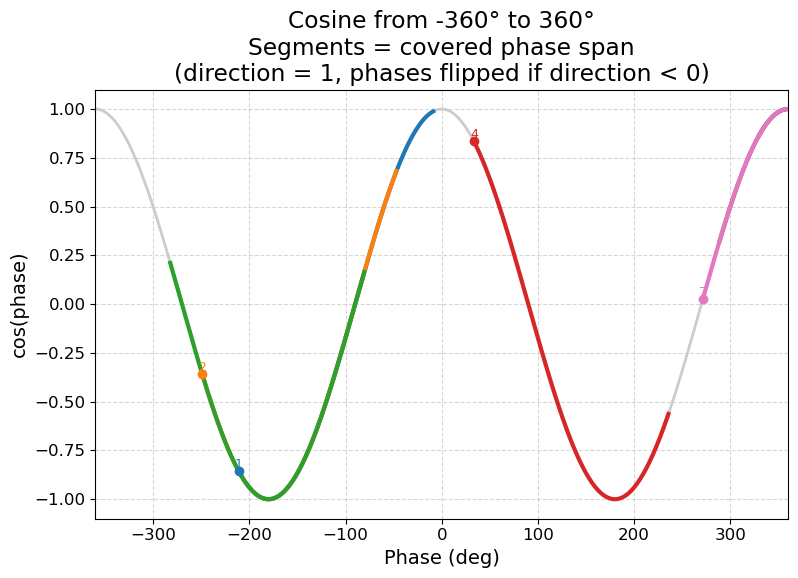

In [9]:
# %%
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# Pick which ROI CSV to load
#   - If ROI_NAME is not None: load that exact ROI folder
#   - Else: auto-pick the most recently modified ROI CSV
#
# CSV format (new):
#   image_index, wavelength_km, pt1, pt2, ..., ptN
# ------------------------------------------------------------

ROI_NAME = "roi_2_center_140_120"

frame_dir = Path(TIFF_DIR)

if OVERLAY_DIR is not None:
    overlay_base = Path(OVERLAY_DIR)
else:
    overlay_base = frame_dir / "overlays_crests_phase"

# Multi-ROI: CSV is in overlay_base/<roi_name>/crest_relative_amplitude_evolution.csv
# Single-ROI (old): CSV is in overlay_base/crest_relative_amplitude_evolution.csv
single_csv = overlay_base / "crest_relative_amplitude_evolution.csv"

if ROI_NAME is not None:
    csv_path = overlay_base / ROI_NAME / "crest_relative_amplitude_evolution.csv"
else:
    # Prefer multi-ROI CSVs if they exist; otherwise fall back to single-ROI location
    roi_csvs = sorted(overlay_base.glob("*/crest_relative_amplitude_evolution.csv"))
    if roi_csvs:
        csv_path = max(roi_csvs, key=lambda p: p.stat().st_mtime)  # newest
    else:
        csv_path = single_csv

print("Loading CSV from:", csv_path)
if not csv_path.exists():
    raise FileNotFoundError(
        f"CSV not found at {csv_path}.\n"
        f"Tip: set ROI_NAME to one of the subfolders inside:\n  {overlay_base}"
    )

# ------------------------------------------------------------
# Read header to figure out column indices robustly
# ------------------------------------------------------------
with open(csv_path, "r", newline="") as f:
    header = f.readline().strip().split(",")

# Expected: image_index, wavelength_km, pt1, pt2, ...
if len(header) < 3:
    raise ValueError(f"CSV header looks too short: {header}")

header_lc = [h.strip().lower() for h in header]

def _find_col(name: str) -> int:
    name = name.lower()
    if name not in header_lc:
        raise ValueError(f"Column '{name}' not found in CSV header: {header}")
    return header_lc.index(name)

col_t = _find_col("image_index")

# New CSVs have wavelength_km; old ones may not.
has_wavelength = "wavelength_km" in header_lc
col_lam = header_lc.index("wavelength_km") if has_wavelength else None

pt_cols = [i for i, h in enumerate(header_lc) if h.startswith("pt")]
if not pt_cols:
    # fallback: assume everything after image_index (and wavelength if present) are points
    start = 2 if has_wavelength else 1
    pt_cols = list(range(start, len(header_lc)))

pt_names = [header[i].strip() for i in pt_cols]

print("Detected columns:")
print("  image_index ->", header[col_t])
print("  wavelength_km ->", (header[col_lam] if has_wavelength else "NOT PRESENT"))
print("  points ->", pt_names)

# --- Load numeric data ---
data = np.genfromtxt(csv_path, delimiter=",", skip_header=1)

# Handle edge case: single row CSV becomes 1D
if data.ndim == 1:
    data = data[None, :]

t = data[:, col_t]  # image indices (as saved)
t = t.astype(float)

if has_wavelength:
    wavelength_km = data[:, col_lam].astype(float)
else:
    wavelength_km = None

Y = data[:, pt_cols].astype(float)  # shape (n_frames, n_pts)
n_frames, n_pts = Y.shape

print("Data shape (frames, points):", Y.shape)
if has_wavelength:
    print("Wavelength column loaded (km). Example stats:",
          f"min={np.nanmin(wavelength_km):.2f}, median={np.nanmedian(wavelength_km):.2f}, max={np.nanmax(wavelength_km):.2f}")

# --- Define a consistent color set for all plots (match default Matplotlib cycle) ---
base_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]
colors = [base_colors[j % len(base_colors)] for j in range(n_pts)]

# --- Initial guess for a (same as before) ---
a0_deg = 360 / 10           # deg per frame
a0 = np.deg2rad(a0_deg)     # rad per frame
print(f"Initial a0 ≈ {a0_deg:.6f} deg per frame")

# --- Grid search around a, with model y = cos(a t + b) (A=1, C0=0) ---
f_min, f_max = 0.4, 1.6     # ±60% around a0; tighten if needed
n_trial = 201               # number of trial a values
n_b = 720                   # number of trial b values (0..2π)

a_trial_deg = a0_deg * np.linspace(f_min, f_max, n_trial)
a_trial = np.deg2rad(a_trial_deg)
b_grid = np.linspace(0.0, 2.0 * np.pi, n_b, endpoint=False)

errors = np.zeros(n_trial)

for k, a_k in enumerate(a_trial):
    base_phase = a_k * t
    phase_mat = base_phase[:, None] + b_grid[None, :]
    cos_mat = np.cos(phase_mat)

    sse_total = 0.0
    for j in range(n_pts):
        y = Y[:, j][:, None]
        sse_b = np.sum((y - cos_mat) ** 2, axis=0)
        sse_total += np.min(sse_b)

    errors[k] = sse_total

best_idx = int(np.argmin(errors))
best_a = a_trial[best_idx]
best_a_deg = a_trial_deg[best_idx]

print()
print("Best a from grid search (model y = cos(a t + b)):")
print(f"  a_best ≈ {best_a_deg:.6f} deg per frame "
      f"(initial {a0_deg:.6f}, factor {best_a_deg/a0_deg:.3f})")
print(f"  SSE_min = {errors[best_idx]:.4f}")

plt.figure(figsize=(8, 4))
plt.plot(a_trial_deg, errors, "-")
plt.axvline(best_a_deg, color="r", linestyle="--", label="best a")
plt.axvline(a0_deg, color="k", linestyle=":", label="initial a0")
plt.xlabel("a (deg per frame)")
plt.ylabel("Total SSE over all points")
plt.title("Grid search for phase speed a\n(model: y = cos(a t + b))")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

# --- For the best a, find best b for each point ---
b_best = np.zeros(n_pts)
sse_per_point = np.zeros(n_pts)

base_phase_best = best_a * t
phase_mat_best = base_phase_best[:, None] + b_grid[None, :]
cos_mat_best = np.cos(phase_mat_best)

print("\nPer-point best phases (model y = cos(a t + b), A=1, C0=0):")
for j in range(n_pts):
    y = Y[:, j][:, None]
    sse_b = np.sum((y - cos_mat_best) ** 2, axis=0)
    k_b = int(np.argmin(sse_b))
    b_star = b_grid[k_b]
    b_best[j] = b_star
    sse_per_point[j] = sse_b[k_b]

    print(f"  {pt_names[j]}: b ≈ {b_star:.3f} rad ({np.degrees(b_star):.1f} deg), "
          f"SSE={sse_b[k_b]:.4f}")

t_fine = np.linspace(t.min(), t.max(), 500)

plt.figure(figsize=(10, 6))
for j in range(n_pts):
    col = colors[j]
    plt.plot(t, Y[:, j], "o", ms=4, alpha=0.6, color=col)
    y_fit = np.cos(best_a * t_fine + b_best[j])
    plt.plot(t_fine, y_fit, "-", lw=2, color=col, label=pt_names[j])

plt.xlabel("Image index")
plt.ylabel("Local relative amplitude")
plt.title(
    r"Fits $y \approx \cos(a t + b)$ "
    rf"with best $a \approx {best_a_deg:.3f}^\circ$/frame"
)
plt.grid(True)
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout(rect=[0, 0, 0.8, 1])
plt.show()

# %%
# ============================================================
#   Single Cosine Summary Plot (No wrap, custom shifting)
# ============================================================

direction = 1  # +1 = original direction, -1 = wave goes the other way

phase_shift_per_frame_deg = direction * best_a_deg
n_frames = len(t)
delta_t = n_frames - 1
total_phase_span_deg = phase_shift_per_frame_deg * delta_t

print(f"Direction = {direction} (−1 means opposite propagation)")
print(f"Phase shift per frame = {phase_shift_per_frame_deg:.4f} deg")
print(f"Frames = {n_frames}, steps = {delta_t}")
print(f"Total phase span per curve ≈ {total_phase_span_deg:.2f} deg")

phi_deg = np.linspace(-360, 360, 2000)
phi = np.radians(phi_deg)
cos_phi = np.cos(phi)

start_deg = np.degrees(b_best)
if direction < 0:
    start_deg = -start_deg

start_deg = start_deg % 360
# Keep your manual shifting logic (assumes at least 3 points)
if n_pts >= 1: start_deg[0] -= 360
if n_pts >= 2: start_deg[1] -= 360
if n_pts >= 3: start_deg[2] -= 360
if direction < 0 and n_pts >= 4:
    start_deg[3] -= 360

end_deg = start_deg + total_phase_span_deg

plt.figure(figsize=(10, 6))
plt.plot(phi_deg, cos_phi, color="0.8", lw=2, label="cosine")

for j in range(n_pts):
    c = colors[j]
    s0 = start_deg[j]
    s1 = end_deg[j]

    lo, hi = sorted((s0, s1))
    mask = (phi_deg >= lo) & (phi_deg <= hi)
    phi_seg = phi_deg[mask]
    cos_seg = cos_phi[mask] if np.any(mask) else []

    if len(phi_seg) > 0:
        plt.plot(phi_seg, cos_seg, lw=3, color=c, label=pt_names[j] if j == 0 else None)

    if -280 <= s0 <= 280:
        y0 = np.cos(np.radians(s0))
        plt.scatter([s0], [y0], color=c, zorder=4)
        plt.text(s0, y0, f"{j+1}", fontsize=9, ha="center", va="bottom", color=c)

plt.xlabel("Phase (deg)")
plt.ylabel("cos(phase)")
plt.title(
    "Cosine from -360° to 360°\n"
    "Segments = covered phase span\n"
    f"(direction = {direction}, phases flipped if direction < 0)"
)
plt.xlim(-360, 360)
plt.grid(True, linestyle="--", alpha=0.5)
plt.tight_layout(rect=[0, 0, 0.82, 1])
plt.show()


## Running sliding-window analysis
The phase speed is evaluated over a 333-s window (11 frames), allowing it to vary in time and capture changes in phase speed.

Running windows: WINDOW=4, STEP=1, total windows=8

First window only plots
Rows 0..3 (frames 0..3)
Best a = 19.37 deg/frame
SSE_min = 0.1246
Avg λ = 29.78 km
Phase speed = 48.55 m/s (Δt=33s)


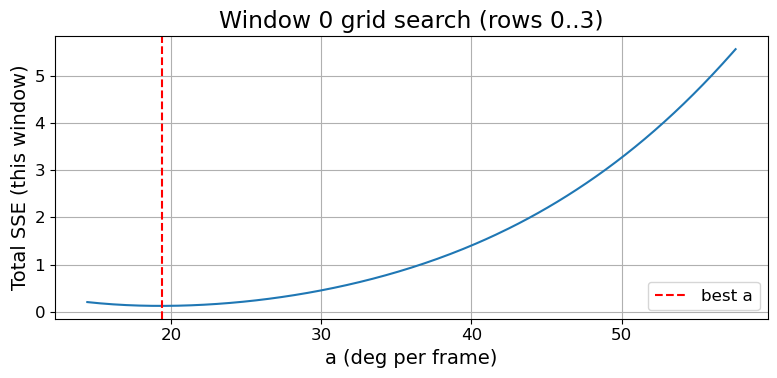

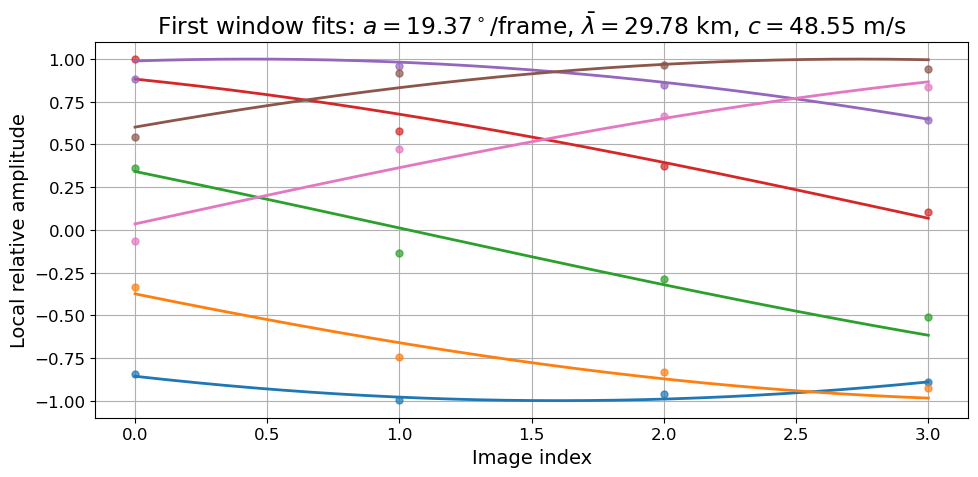


Running-fit summary table:
 window_index  start_row  end_row start_frame end_frame best_a_deg_per_frame avg_wavelength_km phase_speed_m_per_s  SSE_min
            0          0        3        0.00      3.00                19.37             29.78               48.55 0.124638
            1          1        4        1.00      4.00                16.56             30.20               42.10 0.046812
            2          2        5        2.00      5.00                19.15             29.78               48.01 0.041095
            3          3        6        3.00      6.00                20.88             28.96               50.89 0.169579
            4          4        7        4.00      7.00                20.23             28.13               47.91 0.182865
            5          5        8        5.00      8.00                14.40             23.76               28.80 1.421655
            6          6        9        6.00      9.00                15.26             23.76          

In [10]:
# %%
# ============================================================
# Running (sliding-window) grid search for a
#   Fits y ≈ cos(a t + b) within small windows of rows
#   Also computes phase speed per window using:
#       c = (λ / T) = λ * f
#       where f = (a / 360) / Δt_frame
#       Δt_frame = 33 s
#
# CSV has wavelength_km per frame (loaded earlier as wavelength_km).
# Table adds:
#   - avg_wavelength_km
#   - phase_speed_m_per_s
#
# Formatting:
#   - Two decimal places for most stats
#   - SSE kept at full precision (or 4 decimals in prints)
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# User settings
# -----------------------------
WINDOW = 4          # try 3 or 4
STEP = 1
SHOW_FIRST_WINDOW_PLOTS = True

DT_FRAME_S = 33.0   # seconds between frames

# -----------------------------
# Safety checks
# -----------------------------
n_frames, n_pts = Y.shape

if WINDOW < 3:
    raise ValueError("WINDOW is too small. Use 3 or 4.")
if n_frames < WINDOW:
    raise ValueError(f"Not enough rows: n_frames={n_frames}, WINDOW={WINDOW}")

# Wavelength series must exist (from the updated CSV-reading cell)
if "wavelength_km" not in globals() or wavelength_km is None:
    raise ValueError(
        "wavelength_km was not found. Make sure you loaded the new CSV format "
        "and have `wavelength_km = data[:, col_lam]` in the previous cell."
    )
if len(wavelength_km) != n_frames:
    raise ValueError(
        f"wavelength_km length ({len(wavelength_km)}) does not match Y rows ({n_frames})."
    )

# Reuse your existing grids if they exist, otherwise define them
try:
    a_trial_deg
    a_trial
    b_grid
except NameError:
    a0_deg = 180 / 10
    f_min, f_max = 0.4, 1.6
    n_trial = 201
    n_b = 720
    a_trial_deg = a0_deg * np.linspace(f_min, f_max, n_trial)
    a_trial = np.deg2rad(a_trial_deg)
    b_grid = np.linspace(0.0, 2.0 * np.pi, n_b, endpoint=False)

results = []  # list of dicts

n_windows = 1 + (n_frames - WINDOW) // STEP
print(f"Running windows: WINDOW={WINDOW}, STEP={STEP}, total windows={n_windows}")

for w_idx, start in enumerate(range(0, n_frames - WINDOW + 1, STEP)):
    end = start + WINDOW  # python slice end (exclusive)

    t_w = t[start:end]                    # (WINDOW,)
    Y_w = Y[start:end, :]                 # (WINDOW, n_pts)
    lam_w_km = wavelength_km[start:end]   # (WINDOW,)

    # Average wavelength for the window (ignore NaNs)
    lam_avg_km = float(np.nanmean(lam_w_km)) if np.any(np.isfinite(lam_w_km)) else np.nan

    errors_w = np.zeros(len(a_trial), dtype=float)

    # Grid search for this window
    for k, a_k in enumerate(a_trial):
        base_phase = a_k * t_w
        phase_mat = base_phase[:, None] + b_grid[None, :]
        cos_mat = np.cos(phase_mat)

        sse_total = 0.0
        for j in range(n_pts):
            yj = Y_w[:, j][:, None]
            sse_b = np.sum((yj - cos_mat) ** 2, axis=0)
            sse_total += np.min(sse_b)
        errors_w[k] = sse_total

    best_k = int(np.argmin(errors_w))
    best_a_deg_w = float(a_trial_deg[best_k])  # deg per frame
    best_a_w = float(a_trial[best_k])          # rad per frame
    sse_min_w = float(errors_w[best_k])

    # Phase speed (m/s)
    if np.isfinite(lam_avg_km):
        phase_speed_mps = 1000.0 * lam_avg_km * (best_a_deg_w / 360.0) / DT_FRAME_S
    else:
        phase_speed_mps = np.nan

    results.append({
        "window_index": w_idx,
        "start_row": int(start),
        "end_row": int(end - 1),
        "start_frame": float(t_w[0]),
        "end_frame": float(t_w[-1]),
        "best_a_deg_per_frame": best_a_deg_w,
        "SSE_min": sse_min_w,
        "avg_wavelength_km": lam_avg_km,
        "phase_speed_m_per_s": float(phase_speed_mps),
    })

    # ------------------------------------------------------------
    # First-window plots only
    # ------------------------------------------------------------
    if SHOW_FIRST_WINDOW_PLOTS and w_idx == 0:
        print("\nFirst window only plots")
        print(f"Rows {start}..{end-1} (frames {t_w[0]:.0f}..{t_w[-1]:.0f})")
        print(f"Best a = {best_a_deg_w:.2f} deg/frame")
        print(f"SSE_min = {sse_min_w:.4f}")
        print(f"Avg λ = {lam_avg_km:.2f} km")
        print(f"Phase speed = {phase_speed_mps:.2f} m/s (Δt={DT_FRAME_S:.0f}s)")

        plt.figure(figsize=(8, 4))
        plt.plot(a_trial_deg, errors_w, "-")
        plt.axvline(best_a_deg_w, color="r", linestyle="--", label="best a")
        plt.xlabel("a (deg per frame)")
        plt.ylabel("Total SSE (this window)")
        plt.title(f"Window 0 grid search (rows {start}..{end-1})")
        plt.grid(True)
        plt.legend()
        plt.tight_layout()
        plt.show()

        # Data vs fitted curves
        base_phase_best = best_a_w * t_w
        phase_mat_best = base_phase_best[:, None] + b_grid[None, :]
        cos_mat_best = np.cos(phase_mat_best)

        b_best_w = np.zeros(n_pts)
        for j in range(n_pts):
            yj = Y_w[:, j][:, None]
            sse_b = np.sum((yj - cos_mat_best) ** 2, axis=0)
            b_best_w[j] = b_grid[int(np.argmin(sse_b))]

        t_fine = np.linspace(t_w.min(), t_w.max(), 200)
        plt.figure(figsize=(10, 5))
        for j in range(n_pts):
            col = colors[j]
            plt.plot(t_w, Y_w[:, j], "o", ms=5, alpha=0.7, color=col)
            plt.plot(t_fine, np.cos(best_a_w * t_fine + b_best_w[j]), "-", lw=2, color=col)

        plt.xlabel("Image index")
        plt.ylabel("Local relative amplitude")
        plt.title(
            rf"First window fits: $a = {best_a_deg_w:.2f}^\circ$/frame, "
            rf"$\bar{{\lambda}} = {lam_avg_km:.2f}$ km, "
            rf"$c = {phase_speed_mps:.2f}$ m/s"
        )
        plt.grid(True)
        plt.tight_layout()
        plt.show()

# -----------------------------
# Print table
# -----------------------------
try:
    import pandas as pd
    df = pd.DataFrame(results)

    df_show = df[[
        "window_index", "start_row", "end_row",
        "start_frame", "end_frame",
        "best_a_deg_per_frame", "avg_wavelength_km",
        "phase_speed_m_per_s", "SSE_min"
    ]].copy()

    # Format numeric columns (except SSE)
    fmt_cols = [
        "start_frame", "end_frame",
        "best_a_deg_per_frame",
        "avg_wavelength_km",
        "phase_speed_m_per_s",
    ]
    for c in fmt_cols:
        df_show[c] = df_show[c].map(lambda x: f"{x:.2f}" if np.isfinite(x) else "nan")

    print("\nRunning-fit summary table:")
    print(df_show.to_string(index=False))

except Exception:
    print("\nRunning-fit summary table:")
    for r in results:
        print(r)
